In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf
import matplotlib.font_manager as fm
print('Matplotlib font cache cleared. Please restart the runtime for changes to take effect.')

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (16.2 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118194 files and direct

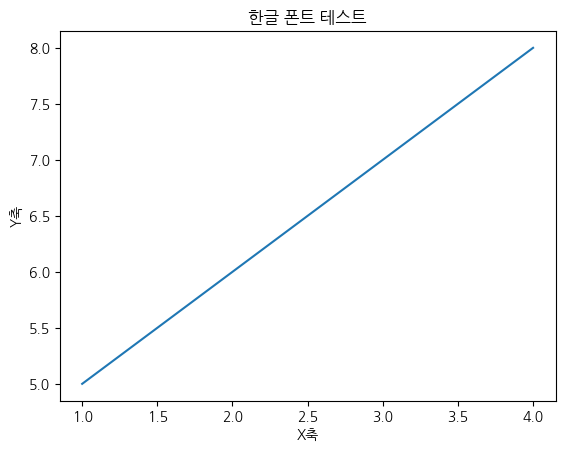

In [ ]:
# prompt: 한글 폰트 matplotlib에 적용 코드

import matplotlib.pyplot as plt

# 한글 폰트 설정 (NanumGothic)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 예시 그래프 출력
plt.plot([1, 2, 3, 4], [5, 6, 7, 8])
plt.xlabel("X축")
plt.ylabel("Y축")
plt.title("한글 폰트 테스트")
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# -----------------------------
# 1. 데이터 불러오기
# -----------------------------
df_og = pd.read_excel("/content/drive/MyDrive/Data Visualization/과제 (1)/202406 가맹점 데이터 (1).xlsx의 사본")
df = df_og.copy()

print("데이터 크기:", df.shape)
print("\n컬럼명:")
print(df.columns.tolist())
print("\n처음 5행:")
print(df.head())

데이터 크기: (1048575, 13)

컬럼명:
['가맹점명', '사업자등록번호', '광역시도', '시군구', '읍면동', '우편번호', 'X좌표', 'Y좌표', '대분류', '중분류', '소분류', '개업일자', '폐업일자']

처음 5행:
         가맹점명       사업자등록번호 광역시도  시군구    읍면동     우편번호         X좌표        Y좌표  \
0        섬꽃농원  3.879102e+09   전남  신안군    도초면  58852.0  125.934316  34.700156   
1        대성마트  7.622601e+09   제주  제주시    한림읍  63032.0  126.261589  33.415734   
2  속편한드림 내과의원  7.309302e+09   제주  제주시    노형동  63083.0  126.477798  33.484445   
3         세계로  4.129005e+09   전남  함평군    월야면  57124.0  126.627176  35.179938   
4    (주)디엔피테크  1.318612e+09   인천  남동구  논현고잔동  21695.0  126.685747  37.402538   

         대분류          중분류   소분류      개업일자  폐업일자  
0  스포츠/문화/레저  스포츠/문화/레저용품    화원  20230612   NaN  
1         유통     할인점/슈퍼마켓  생활잡화  20200625   NaN  
2         의료           병원  개인병원  20220915   NaN  
3  스포츠/문화/레저  스포츠/문화/레저용품    화원  20080107   NaN  
4         기타           기타    기타  20230925   NaN  


# 상권데이터 아이디어.
1. 데이터 분석 및 전처리:  대분류를 통해서 각 대분류간 폐업률 알아보기
*  폐업률 적은 순으로 데이터를 정렬하여 개업일자도 있으니 오래된 가맹점들을 알아내고
* 어떤 종류의 산업이 오랫동안 유지가 가능한지 어떤 종류의 산업이 폐업을 하기 쉬운지도 알아내기

2.  지도에 가맹점 뿌리기 -> 각 업종을 색을 다르게 표기하여 지도에 나타내고 어떤 지역에 어떤 종류의 상업이 많은지를 분석해보기

3. 예측 모델링 : 새로운 변수를 생성하여 예측변수를 활용하여... 어떤 종류의 업종이 오랫동안 유지를 할 수있는지. 또는 어떤 지역에서 어떤 업종이 가장 폐업률이 낮아 창업을 하기 적절한지를 알아보기.







# 문제정의

1. 데이터 시각화 군집화를 통해 각 지역의 상권 분류 무슨 상권이 비중이 큰지
그리고 그 분류된 상위권 변수의 폐업률 비교
2. 어떤 산업률이 폐업률이 가장 적은지. 그리고 예측 모델링을 통하여 어느 지역에 어떤 산업이 가장 폐업률이 적게 성공할 수 있는 산업을 분석하기.

1. 데이터 정보

* 가맹점명: 가맹점 이름 (텍스트)
* 사업자등록번호: 사업자 등록 번호 (숫자)
* 광역시도, 시군구, 읍면동, 우편번호: 주소 관련 정보 (텍스트/숫자)
* X좌표, Y좌표: 지리적 좌표 (숫자)
* 대분류, 중분류, 소분류: 업종 분류 정보 (텍스트)
* 개업일자: 개업 날짜 (정수형, 8자리 숫자 형식 ex:YYYYMMDD)
* 폐업일자: 폐업 날짜 (실수형, 결측치가 많음)


2. 데이터 전처리에서 해야될 것

* 날짜 컬럼 변환: 개업일자와 폐업일자를 datetime 타입으로 변환
* 결측치 확인 및 처리: 특히 광역시도, 시군구, 읍면동, 우편번호, X좌표, Y좌표와 같은 주소 및 좌표 관련 컬럼의 결측치를 확인하고 처리 방안 모색 ( 폐업일자의 경우는 결측치의 경우 현재 영업중으로 간주)






In [ ]:
df = df_og.copy()
df.head()

,가맹점명,사업자등록번호,광역시도,시군구,읍면동,우편번호,X좌표,Y좌표,대분류,중분류,소분류,개업일자,폐업일자
0,섬꽃농원,3.879102e+09,전남,신안군,도초면,58852.0,125.934316,34.700156,스포츠/문화/레저,스포츠/문화/레저용품,화원,20230612,NaN
1,대성마트,7.622601e+09,제주,제주시,한림읍,63032.0,126.261589,33.415734,유통,할인점/슈퍼마켓,생활잡화,20200625,NaN
2,속편한드림 내과의원,7.309302e+09,제주,제주시,노형동,63083.0,126.477798,33.484445,의료,병원,개인병원,20220915,NaN
3,세계로,4.129005e+09,전남,함평군,월야면,57124.0,126.627176,35.179938,스포츠/문화/레저,스포츠/문화/레저용품,화원,20080107,NaN
4,(주)디엔피테크,1.318612e+09,인천,남동구,논현고잔동,21695.0,126.685747,37.402538,기타,기타,기타,20230925,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 13 columns):
 #   Column   Non-Null Count    Dtype  
---  ------   --------------    -----  
 0   가맹점명     1048574 non-null  object 
 1   사업자등록번호  1048574 non-null  float64
 2   광역시도     1039623 non-null  object 
 3   시군구      1039623 non-null  object 
 4   읍면동      1039623 non-null  object 
 5   우편번호     1039623 non-null  float64
 6   X좌표      1039623 non-null  float64
 7   Y좌표      1039623 non-null  float64
 8   대분류      1048575 non-null  object 
 9   중분류      1048575 non-null  object 
 10  소분류      1048575 non-null  object 
 11  개업일자     1048575 non-null  int64  
 12  폐업일자     28633 non-null    float64
dtypes: float64(5), int64(1), object(7)
memory usage: 104.0+ MB


In [ ]:

# -----------------------------
#      결측치 확인
# -----------------------------
print("\n결측치 확인:")
print(df.isnull().sum())


결측치 확인:
가맹점명             1
사업자등록번호          1
광역시도          8952
시군구           8952
읍면동           8952
우편번호          8952
X좌표           8952
Y좌표           8952
대분류              0
중분류              0
소분류              0
개업일자             0
폐업일자       1019942
dtype: int64


In [ ]:
import pandas as pd
import numpy as np

# Ensure df starts clean from the original data
df = df_og.copy()

df["사업자등록번호"] = (
    df["사업자등록번호"]
    .fillna(0)
    .astype(np.int64)
    .astype(str)
    .str.zfill(10)
)

df["우편번호"] = (
    df["우편번호"]
    .fillna(0)
    .astype(int)
    .astype(str)
    .str.zfill(5)
)

df["개업일자"] = pd.to_datetime(
    df["개업일자"].astype(str), format="%Y%m%d", errors="coerce"
)

# More robust conversion for '폐업일자':
# Fill NaNs with 0, convert to int then str, then to datetime.
# Values that were originally NaN will become '0' then NaT.
df["폐업일자"] = pd.to_datetime(
    df["폐업일자"].fillna(0).astype(int).astype(str),
    format="%Y%m%d",
    errors="coerce"
)

df.head()

,가맹점명,사업자등록번호,광역시도,시군구,읍면동,우편번호,X좌표,Y좌표,대분류,중분류,소분류,개업일자,폐업일자
0,섬꽃농원,3879101622,전남,신안군,도초면,58852,125.934316,34.700156,스포츠/문화/레저,스포츠/문화/레저용품,화원,2023-06-12,NaT
1,대성마트,7622600923,제주,제주시,한림읍,63032,126.261589,33.415734,유통,할인점/슈퍼마켓,생활잡화,2020-06-25,NaT
2,속편한드림 내과의원,7309301664,제주,제주시,노형동,63083,126.477798,33.484445,의료,병원,개인병원,2022-09-15,NaT
3,세계로,4129005005,전남,함평군,월야면,57124,126.627176,35.179938,스포츠/문화/레저,스포츠/문화/레저용품,화원,2008-01-07,NaT
4,(주)디엔피테크,1318612366,인천,남동구,논현고잔동,21695,126.685747,37.402538,기타,기타,기타,2023-09-25,NaT


In [ ]:
from datetime import date
import pandas as pd
import numpy as np # numpy import 추가

# ────────────────────────────────────────────
# 2. 이상치 제거 (Type conversions are now handled in cell 8ymDS6Zx6R1x)
# ────────────────────────────────────────────
today = pd.Timestamp(date.today())

df = df[~(df["개업일자"] > today)]
df = df[~(df["폐업일자"].notna() & (df["폐업일자"] < df["개업일자"]))]
df = df[df["개업일자"].notna()]

# 가맹점명 / 사업자등록번호 결측 1개 제거
df = df[df["가맹점명"].notna() & (df["사업자등록번호"] != "0000000000")]

df.head()

,가맹점명,사업자등록번호,광역시도,시군구,읍면동,우편번호,X좌표,Y좌표,대분류,중분류,소분류,개업일자,폐업일자
0,섬꽃농원,3879101622,전남,신안군,도초면,58852,125.934316,34.700156,스포츠/문화/레저,스포츠/문화/레저용품,화원,2023-06-12,NaT
1,대성마트,7622600923,제주,제주시,한림읍,63032,126.261589,33.415734,유통,할인점/슈퍼마켓,생활잡화,2020-06-25,NaT
2,속편한드림 내과의원,7309301664,제주,제주시,노형동,63083,126.477798,33.484445,의료,병원,개인병원,2022-09-15,NaT
3,세계로,4129005005,전남,함평군,월야면,57124,126.627176,35.179938,스포츠/문화/레저,스포츠/문화/레저용품,화원,2008-01-07,NaT
4,(주)디엔피테크,1318612366,인천,남동구,논현고잔동,21695,126.685747,37.402538,기타,기타,기타,2023-09-25,NaT


In [ ]:
df_all = df.copy()                         # 전체 (폐업률·모델링용)
df_map = df[df["X좌표"].notna()].copy()    # 좌표 있는 것만 (지도 시각화용)

print("=" * 50)
print(f"df_all (전체)  : {len(df_all):,}행")
print(f" df_map (지도용): {len(df_map):,}행")
print(f" 지도에서 제외되는 행: {len(df_all) - len(df_map):,}행 "
      f"({(len(df_all) - len(df_map)) / len(df_all) * 100:.1f}%)")


df_all (전체)  : 1,048,573행
 df_map (지도용): 1,039,622행
 지도에서 제외되는 행: 8,951행 (0.9%)


파생변수 생성
* 영업기간_일: 개업~폐업 날짜 차이를 숫자로 변환 → 생존분석의 핵심 타겟
* 폐업여부: 폐업일자 유무를 0/1로 명시화 → 머신러닝 모델 입력용
* 개업연도/월: 날짜를 쪼개서 시기별 패턴 포착 (ex. 코로나 시기 개업 여부)
* 상권_소분류_밀도: 같은 동네 동업종 수 → 경쟁 강도를 수치화
* 상권_대분류_다양성: 동네 내 업종 다양성 → 상권 활성화 정도를 수치화

In [ ]:
df["기준일자"]         = df["폐업일자"].fillna(today)
df["영업기간_일"]      = (df["기준일자"] - df["개업일자"]).dt.days
df["영업중"]           = df["폐업일자"].isna().astype(int)
df["폐업여부"]         = (df["영업중"] == 0).astype(int)
df["개업연도"]         = df["개업일자"].dt.year
df["개업월"]           = df["개업일자"].dt.month
df["상권_소분류_밀도"]   = df.groupby(["읍면동", "소분류"])["가맹점명"].transform("count")
df["상권_대분류_다양성"] = df.groupby("읍면동")["대분류"].transform("nunique")
df.drop(columns=["기준일자"], inplace=True)

df.head(5)


,가맹점명,사업자등록번호,광역시도,시군구,읍면동,우편번호,X좌표,Y좌표,대분류,중분류,소분류,개업일자,폐업일자,영업기간_일,영업중,폐업여부,개업연도,개업월,상권_소분류_밀도,상권_대분류_다양성
0,섬꽃농원,3879101622,전남,신안군,도초면,58852,125.934316,34.700156,스포츠/문화/레저,스포츠/문화/레저용품,화원,2023-06-12,NaT,1056,1,0,2023,6,1.0,9.0
1,대성마트,7622600923,제주,제주시,한림읍,63032,126.261589,33.415734,유통,할인점/슈퍼마켓,생활잡화,2020-06-25,NaT,2138,1,0,2020,6,20.0,14.0
2,속편한드림 내과의원,7309301664,제주,제주시,노형동,63083,126.477798,33.484445,의료,병원,개인병원,2022-09-15,NaT,1326,1,0,2022,9,109.0,14.0
3,세계로,4129005005,전남,함평군,월야면,57124,126.627176,35.179938,스포츠/문화/레저,스포츠/문화/레저용품,화원,2008-01-07,NaT,6691,1,0,2008,1,2.0,12.0
4,(주)디엔피테크,1318612366,인천,남동구,논현고잔동,21695,126.685747,37.402538,기타,기타,기타,2023-09-25,NaT,951,1,0,2023,9,262.0,14.0


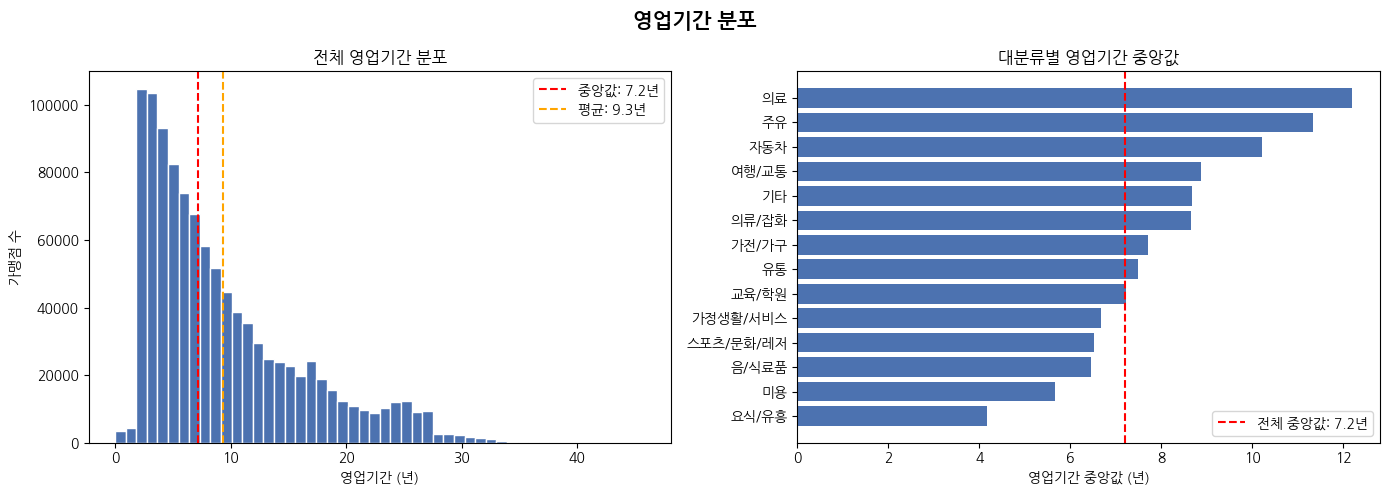

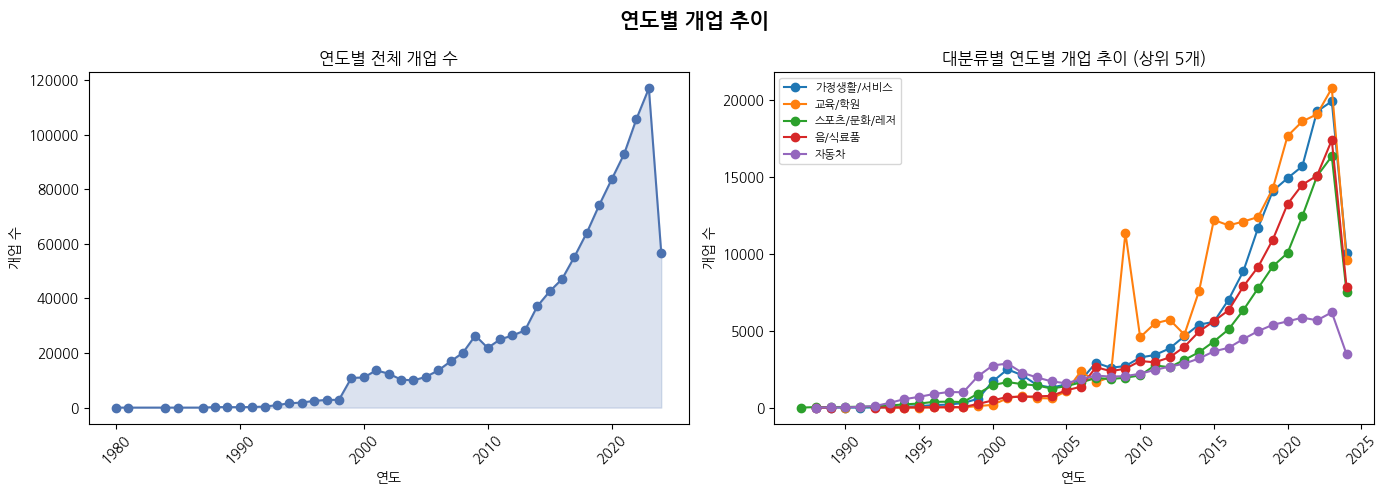

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings("ignore")


# ────────────────────────────────────────────
# 1. 영업기간 분포
# ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("영업기간 분포", fontsize=15, fontweight="bold")

# 영업기간 → 연 단위 변환
df["영업기간_년"] = df["영업기간_일"] / 365

# ① 전체 분포 (히스토그램)
axes[0].hist(df["영업기간_년"], bins=50, color="#4C72B0", edgecolor="white")
axes[0].axvline(df["영업기간_년"].median(), color="red", linestyle="--",
                label=f'중앙값: {df["영업기간_년"].median():.1f}년')
axes[0].axvline(df["영업기간_년"].mean(), color="orange", linestyle="--",
                label=f'평균: {df["영업기간_년"].mean():.1f}년')
axes[0].set_title("전체 영업기간 분포")
axes[0].set_xlabel("영업기간 (년)")
axes[0].set_ylabel("가맹점 수")
axes[0].legend()

# ② 대분류별 영업기간 중앙값 (가로 막대)
median_by_cat = (
    df.groupby("대분류")["영업기간_년"]
    .median()
    .sort_values()
)
axes[1].barh(median_by_cat.index, median_by_cat.values, color="#4C72B0")
axes[1].axvline(df["영업기간_년"].median(), color="red", linestyle="--",
                label=f'전체 중앙값: {df["영업기간_년"].median():.1f}년')
axes[1].set_title("대분류별 영업기간 중앙값")
axes[1].set_xlabel("영업기간 중앙값 (년)")
axes[1].legend()

plt.tight_layout()
plt.savefig("plot_영업기간분포.png", dpi=150, bbox_inches="tight")
plt.show()


# ────────────────────────────────────────────
# 2. 연도별 개업 추이
# ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("연도별 개업 추이", fontsize=15, fontweight="bold")

# ① 전체 연도별 개업 수
yearly = df.groupby("개업연도").size()
axes[0].plot(yearly.index, yearly.values, marker="o", color="#4C72B0")
axes[0].fill_between(yearly.index, yearly.values, alpha=0.2, color="#4C72B0")
axes[0].set_title("연도별 전체 개업 수")
axes[0].set_xlabel("연도")
axes[0].set_ylabel("개업 수")
axes[0].tick_params(axis="x", rotation=45)

# ② 대분류별 연도별 개업 추이 (상위 5개 대분류)
top5 = df["대분류"].value_counts().head(5).index
yearly_cat = (
    df[df["대분류"].isin(top5)]
    .groupby(["개업연도", "대분류"])
    .size()
    .unstack()
)
for col in yearly_cat.columns:
    axes[1].plot(yearly_cat.index, yearly_cat[col], marker="o", label=col)
axes[1].set_title("대분류별 연도별 개업 추이 (상위 5개)")
axes[1].set_xlabel("연도")
axes[1].set_ylabel("개업 수")
axes[1].legend(loc="upper left", fontsize=8)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("plot_연도별개업추이.png", dpi=150, bbox_inches="tight")
plt.show()


▶ 상관계수 행렬
            영업기간_일  폐업여부  개업연도   개업월  상권_소분류_밀도  상권_대분류_다양성   X좌표   Y좌표
영업기간_일        1.00 -0.10 -1.00  0.01      -0.01       -0.00  0.03 -0.04
폐업여부         -0.10  1.00  0.05  0.00      -0.00        0.01 -0.00  0.01
개업연도         -1.00  0.05  1.00 -0.05       0.01        0.00 -0.03  0.04
개업월           0.01  0.00 -0.05  1.00      -0.00       -0.00 -0.00  0.00
상권_소분류_밀도    -0.01 -0.00  0.01 -0.00       1.00        0.12  0.00  0.02
상권_대분류_다양성   -0.00  0.01  0.00 -0.00       0.12        1.00 -0.00  0.03
X좌표           0.03 -0.00 -0.03 -0.00       0.00       -0.00  1.00 -0.44
Y좌표          -0.04  0.01  0.04  0.00       0.02        0.03 -0.44  1.00


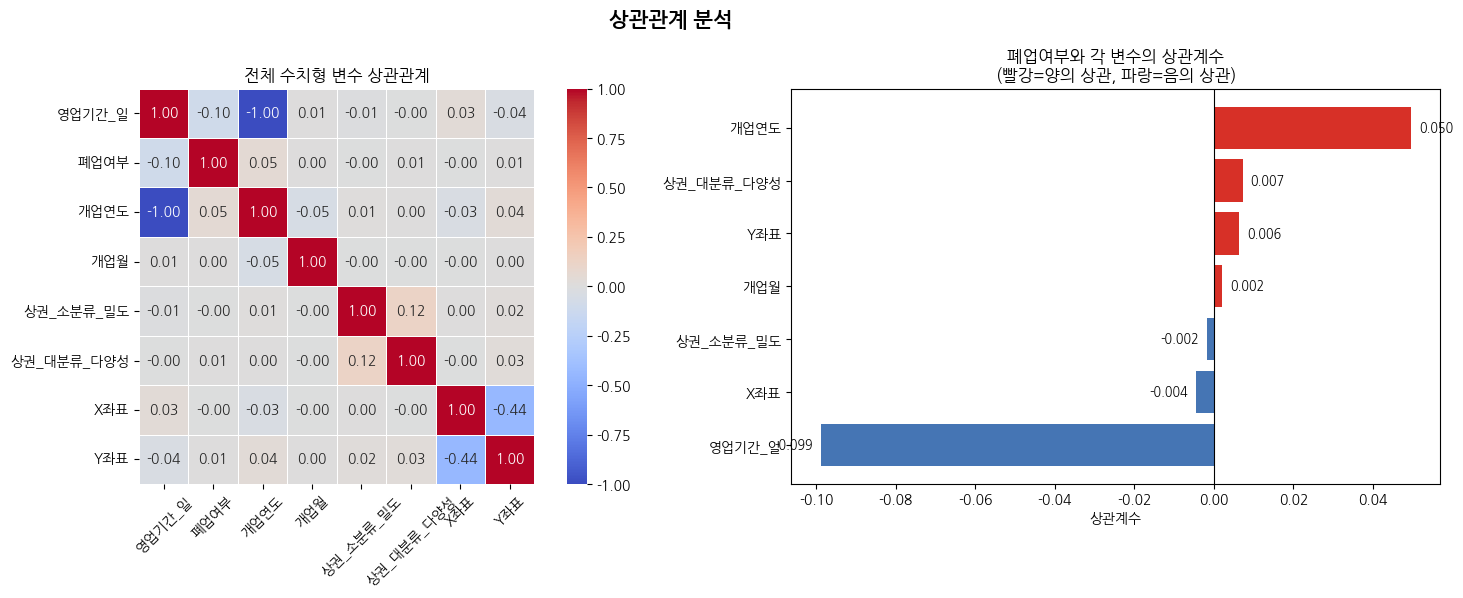


 폐업여부와 상관관계
----------------------------------------
  영업기간_일         : -0.099  (약한 음의 상관관계)
  개업연도           : +0.050  (약한 양의 상관관계)
  상권_대분류_다양성     : +0.007  (약한 양의 상관관계)
  Y좌표            : +0.006  (약한 양의 상관관계)
  X좌표            : -0.004  (약한 음의 상관관계)
  개업월            : +0.002  (약한 양의 상관관계)
  상권_소분류_밀도      : -0.002  (약한 음의 상관관계)


In [ ]:
import seaborn as sns
# ────────────────────────────────────────────
# 1. 상관관계 분석에 쓸 수치형 컬럼 선택
# ────────────────────────────────────────────
num_cols = [
    "영업기간_일",
    "폐업여부",
    "개업연도",
    "개업월",
    "상권_소분류_밀도",
    "상권_대분류_다양성",
    "X좌표",
    "Y좌표",
]

corr = df[num_cols].corr() # df_all 대신 df 사용

print("▶ 상관계수 행렬")
print(corr.round(2).to_string())


# ────────────────────────────────────────────
# 2. 히트맵
# ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("상관관계 분석", fontsize=15, fontweight="bold")

# ① 전체 히트맵
sns.heatmap(
    corr,
    ax=axes[0],
    annot=True,          # 수치 표시
    fmt=".2f",           # 소수점 2자리
    cmap="coolwarm",     # 양/음 상관관계 색상 구분
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
)
axes[0].set_title("전체 수치형 변수 상관관계")
axes[0].tick_params(axis="x", rotation=45)

# ② 폐업여부와의 상관관계만 추출 (막대 그래프)
corr_target = (
    corr["폐업여부"]
    .drop("폐업여부")          # 자기 자신 제외
    .sort_values()
)
colors = ["#d73027" if v > 0 else "#4575b4" for v in corr_target.values]
axes[1].barh(corr_target.index, corr_target.values, color=colors)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("폐업여부와 각 변수의 상관계수\n(빨강=양의 상관, 파랑=음의 상관)")
axes[1].set_xlabel("상관계수")

# 수치 레이블
for i, v in enumerate(corr_target.values):
    axes[1].text(v + (0.002 if v >= 0 else -0.002),
                 i, f"{v:.3f}",
                 va="center",
                 ha="left" if v >= 0 else "right",
                 fontsize=9)

plt.tight_layout()
plt.savefig("plot_상관관계히트맵.png", dpi=150, bbox_inches="tight")
plt.show()


# ────────────────────────────────────────────
# 3. 상관관계 해석 출력
# ────────────────────────────────────────────
print("\n 폐업여부와 상관관계")
print("-" * 40)
for col, val in corr_target.sort_values(key=abs, ascending=False).items():
    direction = "양의" if val > 0 else "음의"
    strength  = "강한" if abs(val) > 0.3 else "약한"
    print(f"  {col:15s}: {val:+.3f}  ({strength} {direction} 상관관계)")

수치형 변수 간 선형 상관관계는 낮게 나타났으며, 이는 폐업에 영향을 미치는 요인이 비선형적이거나 범주형 변수에 기인할 가능성을 시사한다

### 광역시도별 폐업률 분석

'광역시도'는 범주형 변수이므로, 수치형 변수와의 직접적인 상관계수를 구하는 대신 각 지역별 폐업률을 계산하여 비교합니다.

In [ ]:
closure_rate_by_city = df.groupby('광역시도')['폐업여부'].mean().sort_values(ascending=False)
display(closure_rate_by_city.to_frame())

print(" 광역시도별 폐업률 상위 5개")
print(closure_rate_by_city.head(5).to_string())

print(" 광역시도별 폐업률 하위 5개")
print(closure_rate_by_city.tail(5).to_string())

,폐업여부
광역시도,
세종,0.035244
인천,0.030848
경기,0.030349
경남,0.028457
광주,0.027862
대전,0.027055
부산,0.026647
서울,0.026471
대구,0.026234


 광역시도별 폐업률 상위 5개
광역시도
세종    0.035244
인천    0.030848
경기    0.030349
경남    0.028457
광주    0.027862
 광역시도별 폐업률 하위 5개
광역시도
강원    0.024927
전북    0.024901
경북    0.024784
충북    0.024526
전남    0.022371


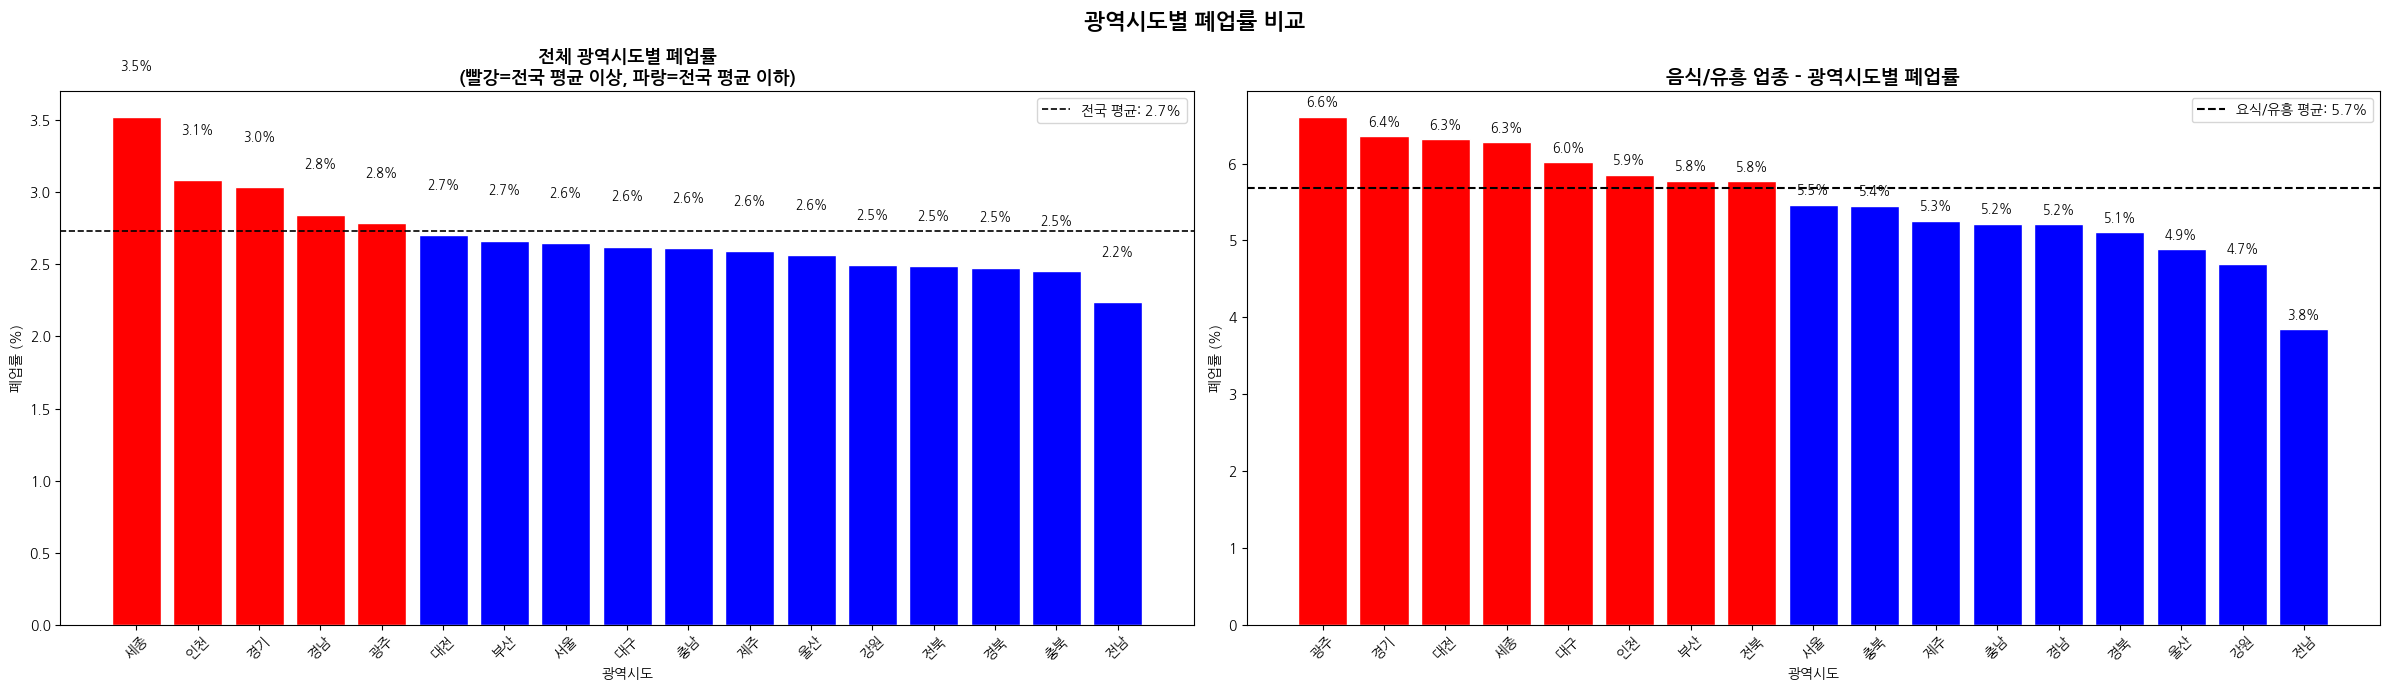

In [ ]:
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

# ────────────────────────────────────────────
# 광역시도별 폐업률 막대그래프 & 음식/유흥 업종 광역시도별 폐업률
# ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(24, 7))
fig.suptitle("광역시도별 폐업률 비교", fontsize=16, fontweight="bold")

# --- 첫 번째 서브플롯: 전체 광역시도별 폐업률 ---
# 전국 평균
national_avg = df["폐업여부"].mean()

# 색상: 평균 이상이면 빨강, 이하면 파랑
colors = ["Red" if v >= national_avg else "Blue"
          for v in closure_rate_by_city.values]

bars = axes[0].bar(closure_rate_by_city.index,
                   closure_rate_by_city.values * 100,
                   color=colors, edgecolor="white")

# 전국 평균선
axes[0].axhline(national_avg * 100, color="black", linestyle="--", linewidth=1.2,
               label=f"전국 평균: {national_avg * 100:.1f}%")

# 막대 위 수치 레이블
for bar, val in zip(bars, closure_rate_by_city.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.3,
                 f"{val * 100:.1f}%",
                 ha="center", va="bottom", fontsize=9)

axes[0].set_title("전체 광역시도별 폐업률\n(빨강=전국 평균 이상, 파랑=전국 평균 이하)",
             fontsize=13, fontweight="bold")
axes[0].set_xlabel("광역시도")
axes[0].set_ylabel("폐업률 (%)")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend()


# --- 두 번째 서브플롯: 음식/유흥 업종 - 광역시도별 폐업률 ---
# 음식/유흥만 필터
df_food = df[df["대분류"] == "요식/유흥"]

# 광역시도별 폐업률
food_by_city = df_food.groupby("광역시도")["폐업여부"].mean().sort_values(ascending=False) * 100

# 음식/유흥 전체 평균
food_avg = df_food["폐업여부"].mean() * 100

# 그래프
colors_food = ["Red" if v >= food_avg else "Blue" for v in food_by_city.values]
bars_food = axes[1].bar(food_by_city.index, food_by_city.values, color=colors_food, edgecolor="white")

axes[1].axhline(food_avg, color="black", linestyle="--", label=f"요식/유흥 평균: {food_avg:.1f}%")

for bar, val in zip(bars_food, food_by_city.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            f"{val:.1f}%", ha="center", va="bottom", fontsize=9)

axes[1].set_title("음식/유흥 업종 - 광역시도별 폐업률", fontsize=14, fontweight="bold")
axes[1].set_xlabel("광역시도")
axes[1].set_ylabel("폐업률 (%)")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend()

plt.tight_layout()
plt.savefig("plot_광역시도별폐업률_비교.png", dpi=150, bbox_inches="tight")
plt.show()

* 전체 광역시도별 폐업률의 경우 : 1~2% 의 편차로 유의미하다고 보기어려움.
* 요식/유흥 업종 광역시도 폐업률의 경우
* 전체 폐업률에서는 지역 간 차이가 1.3%p 로 미미했는데 요식업만 필터링하니 2.8%p 로 차이가 2배 이상 보임.
→ 지역 변수는 전체보다 업종을 특정했을 때 더 의미있는 변수라는 판단.


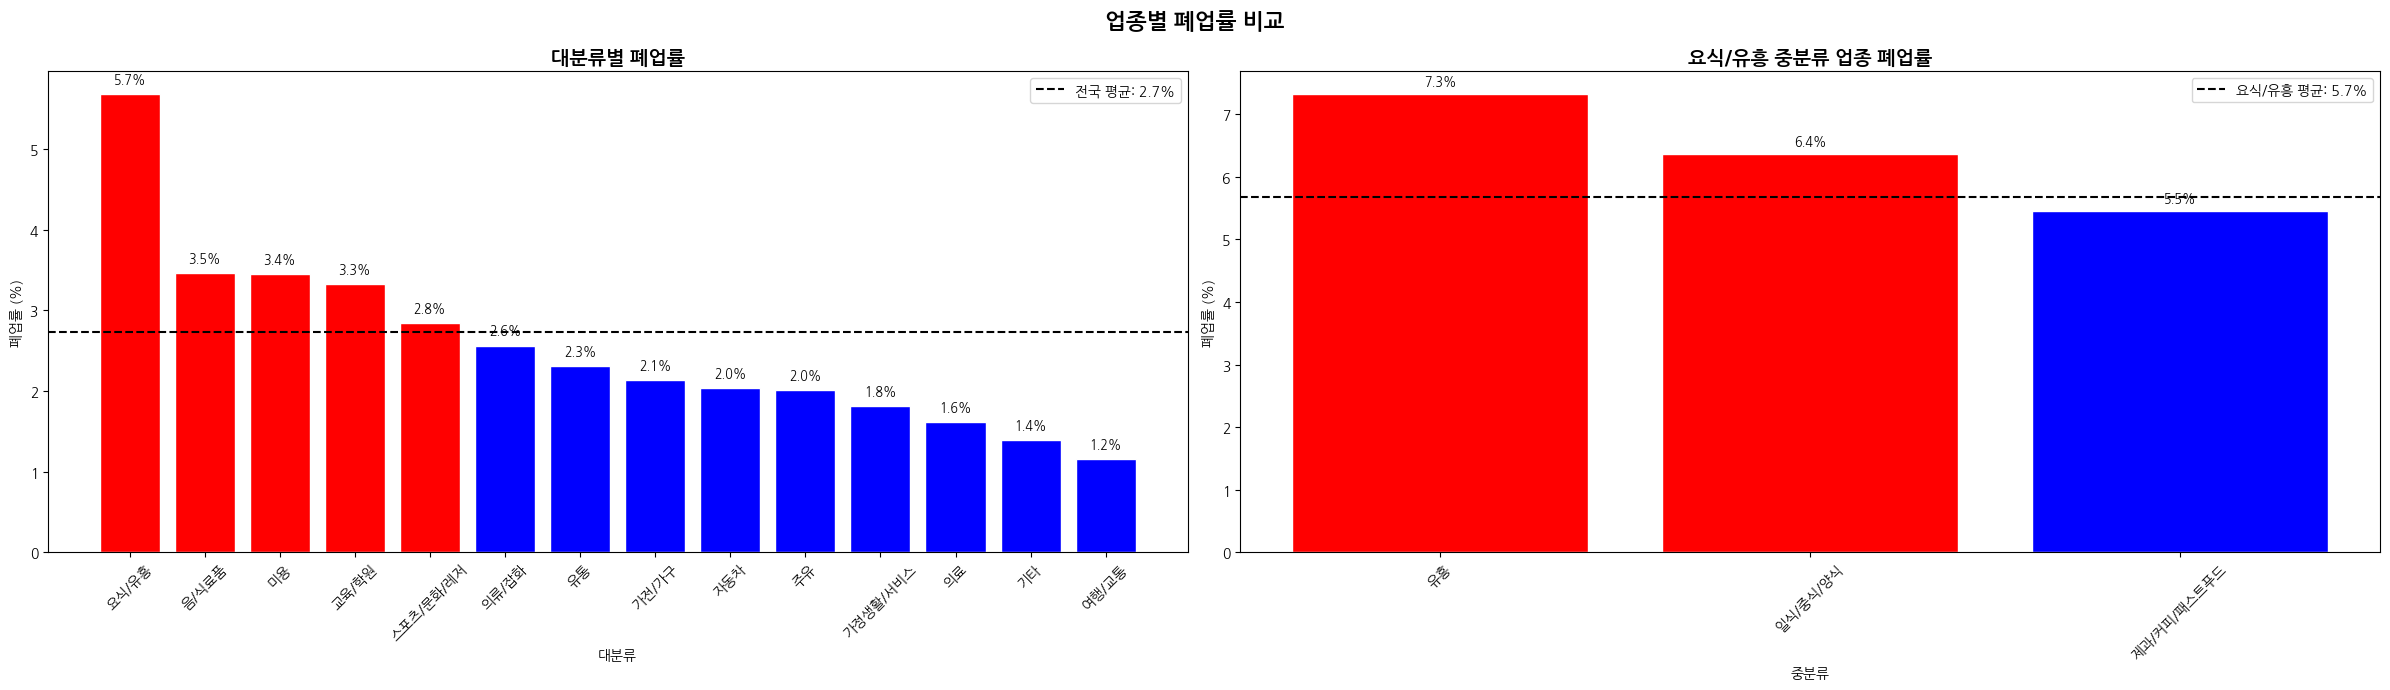

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from datetime import date


# ────────────────────────────────────────────
# 1. 대분류별 폐업률
# ────────────────────────────────────────────

# 대분류별 폐업률 계산
closure_by_cat = df.groupby("대분류")["폐업여부"].mean().sort_values(ascending=False) * 100

# 전국 평균
avg = df["폐업여부"].mean() * 100

# ────────────────────────────────────────────
# 2. 요식/유흥 중분류 업종 폐업률
# ────────────────────────────────────────────

# 음식/유흥만 필터
df_food = df[df["대분류"] == "요식/유흥"]

# 중분류별 폐업률
food_by_mid = df_food.groupby("중분류")["폐업여부"].mean().sort_values(ascending=False) * 100

# 음식/유흥 평균
food_avg = df_food["폐업여부"].mean() * 100


# ────────────────────────────────────────────
# 3. 두 그래프 합치기
# ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(24, 7)) # 1행 2열로 서브플롯 생성
fig.suptitle("업종별 폐업률 비교", fontsize=16, fontweight="bold")

# --- 첫 번째 서브플롯: 대분류별 폐업률 ----
colors_cat = ["Red" if v >= avg else "Blue" for v in closure_by_cat.values] # 색상 리스트 재정의
bars_cat = axes[0].bar(closure_by_cat.index, closure_by_cat.values, color=colors_cat, edgecolor="white")

# 평균선
axes[0].axhline(avg, color="black", linestyle="--", label=f"전국 평균: {avg:.1f}%")

# 막대 위 수치
for bar, val in zip(bars_cat, closure_by_cat.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            f"{val:.1f}%", ha="center", va="bottom", fontsize=9)

axes[0].set_title("대분류별 폐업률", fontsize=14, fontweight="bold")
axes[0].set_xlabel("대분류")
axes[0].set_ylabel("폐업률 (%)")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend()

# --- 두 번째 서브플롯: 요식/유흥 중분류 업종 폐업률 ---
colors_food = ["Red" if v >= food_avg else "Blue" for v in food_by_mid.values]
bars_food = axes[1].bar(food_by_mid.index, food_by_mid.values, color=colors_food, edgecolor="white")

axes[1].axhline(food_avg, color="black", linestyle="--", label=f"요식/유흥 평균: {food_avg:.1f}%")

for bar, val in zip(bars_food, food_by_mid.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            f"{val:.1f}%", ha="center", va="bottom", fontsize=9)

axes[1].set_title("요식/유흥 중분류 업종 폐업률", fontsize=14, fontweight="bold")
axes[1].set_xlabel("중분류")
axes[1].set_ylabel("폐업률 (%)")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()

세 중분류 모두 5% 이상으로 전국 평균의 2배 값.
특히 코로나19로 인하여 큰 영향을 받은 유흥 카테고리가 폐업률이 가장 높음.

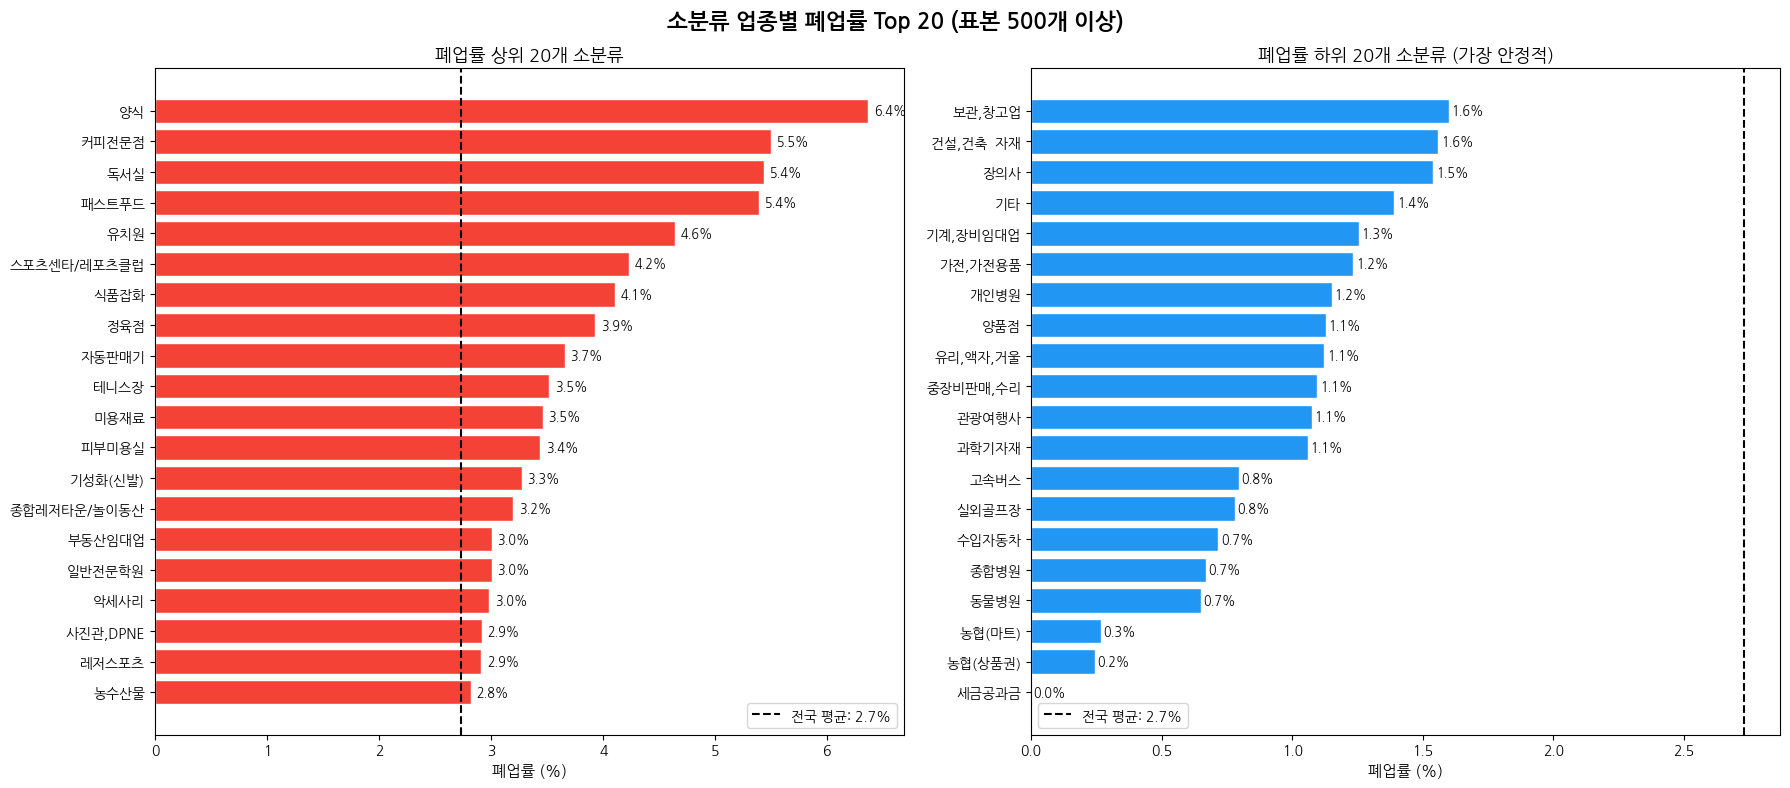

In [ ]:
소분류_통계 = (
    df.groupby('소분류')
    .agg(폐업률=('폐업여부', 'mean'), 가맹점수=('폐업여부', 'count'))
    .query('가맹점수 >= 500')  # 표본 500개 이상만
    .assign(폐업률=lambda x: x['폐업률'] * 100)
)

top20_high = 소분류_통계.nlargest(20, '폐업률')
top20_low  = 소분류_통계.nsmallest(20, '폐업률')

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('소분류 업종별 폐업률 Top 20 (표본 500개 이상)', fontsize=16, fontweight='bold')

# 왼쪽: 폐업률 높은 상위 20개
axes[0].barh(top20_high['폐업률'].index[::-1], top20_high['폐업률'].values[::-1],
             color='#F44336', edgecolor='white')
axes[0].axvline(df['폐업여부'].mean() * 100, color='black', linestyle='--',
                linewidth=1.5, label=f'전국 평균: {df["폐업여부"].mean()*100:.1f}%')
for i, (idx, row) in enumerate(top20_high.iloc[::-1].iterrows()):
    axes[0].text(row['폐업률'] + 0.05, i, f'{row["폐업률"]:.1f}%', va='center', fontsize=9)
axes[0].set_title('폐업률 상위 20개 소분류', fontsize=13)
axes[0].set_xlabel('폐업률 (%)', fontsize=11)
axes[0].legend()

# 오른쪽: 폐업률 낮은 상위 20개
axes[1].barh(top20_low['폐업률'].index, top20_low['폐업률'].values,
             color='#2196F3', edgecolor='white')
axes[1].axvline(df['폐업여부'].mean() * 100, color='black', linestyle='--',
                linewidth=1.5, label=f'전국 평균: {df["폐업여부"].mean()*100:.1f}%')
for i, (idx, row) in enumerate(top20_low.iterrows()):
    axes[1].text(row['폐업률'] + 0.01, i, f'{row["폐업률"]:.1f}%', va='center', fontsize=9)
axes[1].set_title('폐업률 하위 20개 소분류 (가장 안정적)', fontsize=13)
axes[1].set_xlabel('폐업률 (%)', fontsize=11)
axes[1].legend()

plt.tight_layout()
plt.show()

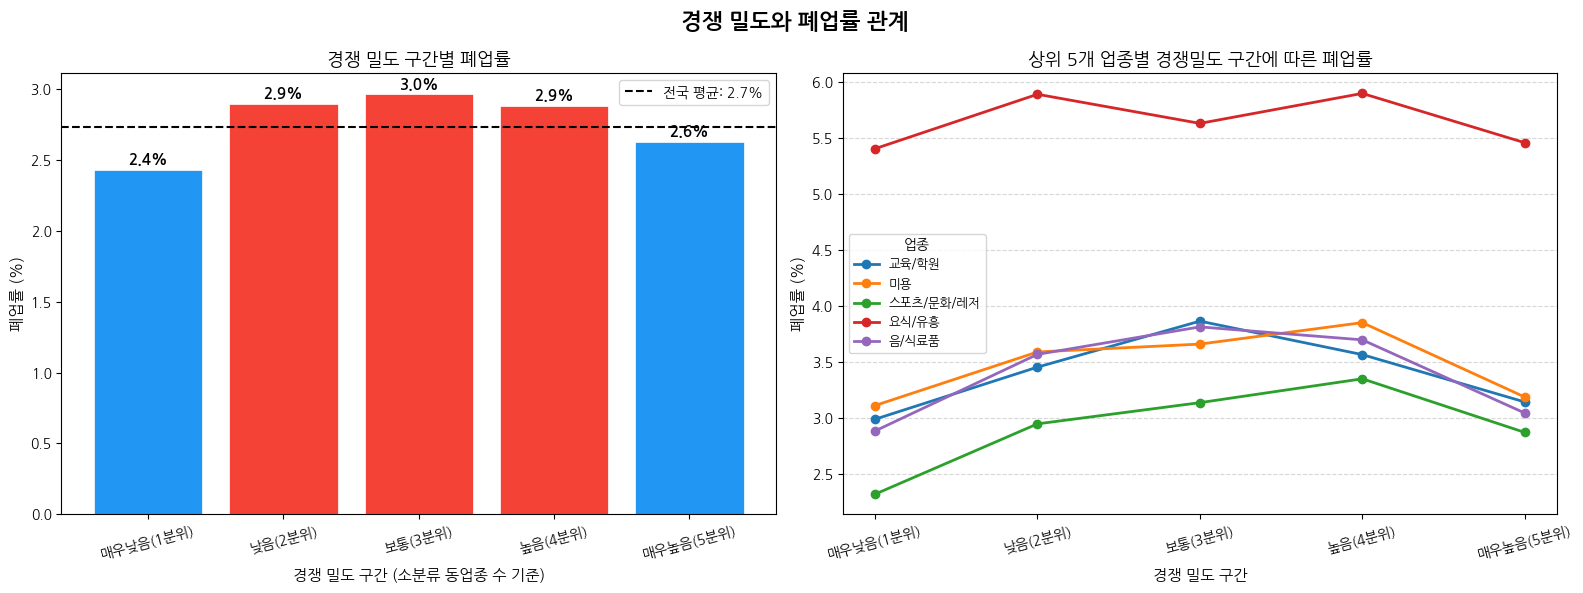

In [ ]:
# ── 경쟁 밀도를 5구간으로 분할 ──
df['경쟁밀도_구간'] = pd.qcut(
    df['상권_소분류_밀도'],
    q=5,
    labels=['매우낮음(1분위)', '낮음(2분위)', '보통(3분위)', '높음(4분위)', '매우높음(5분위)']
)

밀도별 = df.groupby('경쟁밀도_구간', observed=True)['폐업여부'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('경쟁 밀도와 폐업률 관계', fontsize=16, fontweight='bold')

# 왼쪽: 구간별 막대그래프
colors = ['#2196F3' if v < df['폐업여부'].mean() * 100 else '#F44336' for v in 밀도별]
bars = axes[0].bar(밀도별.index, 밀도별.values, color=colors, edgecolor='white', linewidth=0.5)
axes[0].axhline(df['폐업여부'].mean() * 100, color='black', linestyle='--', linewidth=1.5, label=f'전국 평균: {df["폐업여부"].mean()*100:.1f}%')
for bar, val in zip(bars, 밀도별.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('경쟁 밀도 구간별 폐업률', fontsize=13)
axes[0].set_xlabel('경쟁 밀도 구간 (소분류 동업종 수 기준)', fontsize=11)
axes[0].set_ylabel('폐업률 (%)', fontsize=11)
axes[0].legend()
axes[0].tick_params(axis='x', rotation=15)

# 오른쪽: 상위 5개 업종의 경쟁밀도 구간별 폐업률 라인차트
top5_업종 = df.groupby('대분류')['폐업여부'].mean().nlargest(5).index
df_top5 = df[df['대분류'].isin(top5_업종)]
pivot = df_top5.groupby(['경쟁밀도_구간', '대분류'], observed=True)['폐업여부'].mean() * 100
pivot = pivot.unstack('대분류')

for col in pivot.columns:
    axes[1].plot(pivot.index, pivot[col], marker='o', linewidth=2, label=col)
axes[1].set_title('상위 5개 업종별 경쟁밀도 구간에 따른 폐업률', fontsize=13)
axes[1].set_xlabel('경쟁 밀도 구간', fontsize=11)
axes[1].set_ylabel('폐업률 (%)', fontsize=11)
axes[1].legend(title='업종', fontsize=9)
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

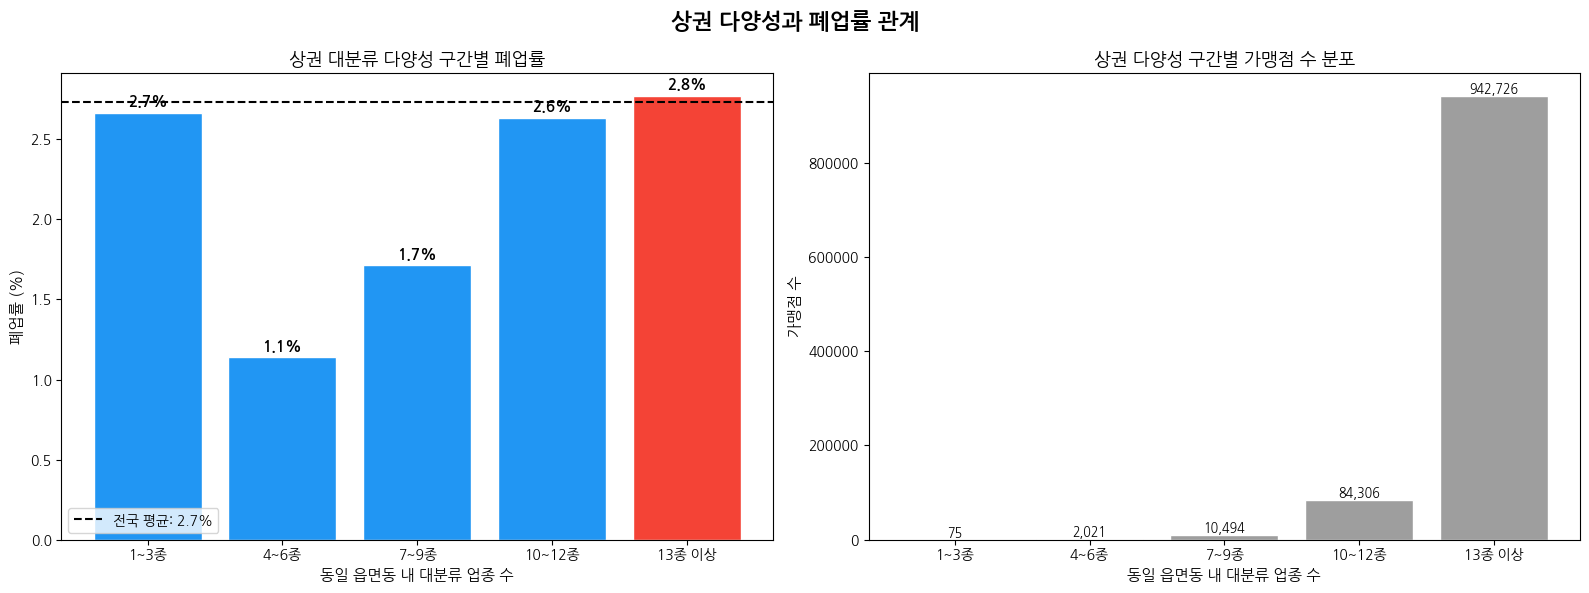

In [ ]:
df['다양성_구간'] = pd.cut(
    df['상권_대분류_다양성'],
    bins=[0, 3, 6, 9, 12, 100],
    labels=['1~3종', '4~6종', '7~9종', '10~12종', '13종 이상']
)

다양성별 = df.groupby('다양성_구간', observed=True)['폐업여부'].mean() * 100
count별  = df.groupby('다양성_구간', observed=True)['폐업여부'].count()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('상권 다양성과 폐업률 관계', fontsize=16, fontweight='bold')

# 왼쪽: 다양성 구간별 폐업률
colors = ['#F44336' if v >= df['폐업여부'].mean() * 100 else '#2196F3' for v in 다양성별]
bars = axes[0].bar(다양성별.index, 다양성별.values, color=colors, edgecolor='white')
axes[0].axhline(df['폐업여부'].mean() * 100, color='black', linestyle='--', linewidth=1.5,
                label=f'전국 평균: {df["폐업여부"].mean()*100:.1f}%')
for bar, val in zip(bars, 다양성별.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('상권 대분류 다양성 구간별 폐업률', fontsize=13)
axes[0].set_xlabel('동일 읍면동 내 대분류 업종 수', fontsize=11)
axes[0].set_ylabel('폐업률 (%)', fontsize=11)
axes[0].legend()

# 오른쪽: 다양성 구간별 가맹점 수 (분포 확인)
axes[1].bar(count별.index, count별.values, color='#9E9E9E', edgecolor='white')
axes[1].set_title('상권 다양성 구간별 가맹점 수 분포', fontsize=13)
axes[1].set_xlabel('동일 읍면동 내 대분류 업종 수', fontsize=11)
axes[1].set_ylabel('가맹점 수', fontsize=11)
for bar, val in zip(axes[1].patches, count별.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{val:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

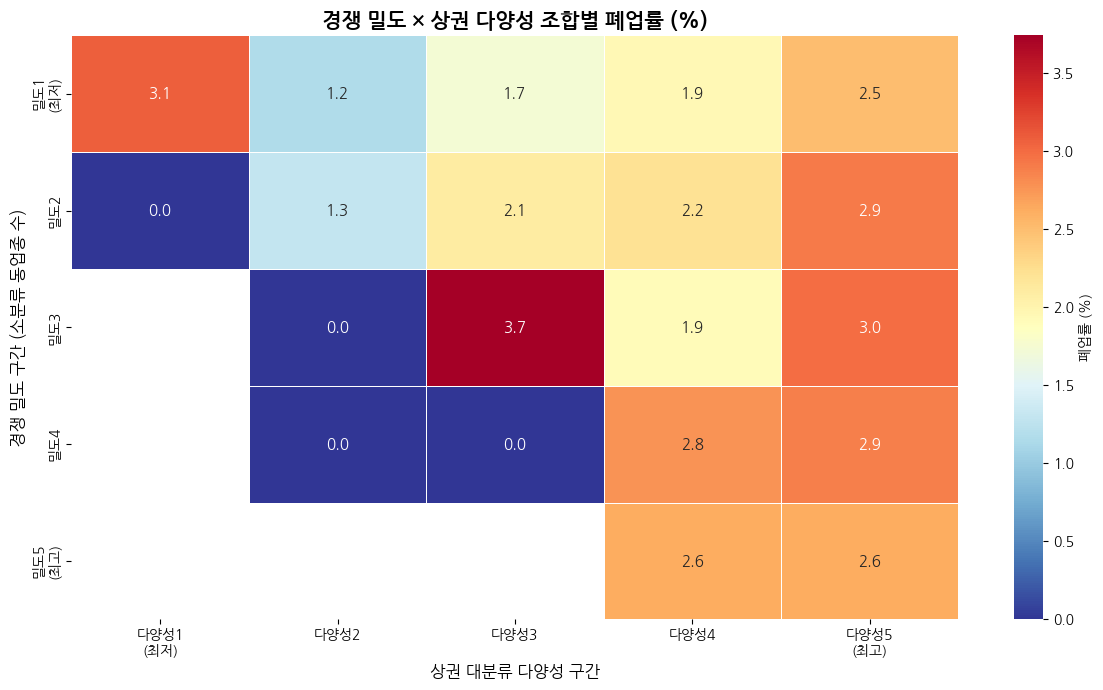

In [ ]:
df['밀도_bin'] = pd.qcut(df['상권_소분류_밀도'], q=5,
                          labels=['밀도1\n(최저)','밀도2','밀도3','밀도4','밀도5\n(최고)'])
df['다양성_bin'] = pd.cut(df['상권_대분류_다양성'], bins=5,
                           labels=['다양성1\n(최저)','다양성2','다양성3','다양성4','다양성5\n(최고)'])

pivot_2d = df.groupby(['밀도_bin', '다양성_bin'], observed=True)['폐업여부'].mean() * 100
pivot_2d = pivot_2d.unstack('다양성_bin')

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(
    pivot_2d, annot=True, fmt='.1f', cmap='RdYlBu_r',
    linewidths=0.5, ax=ax,
    cbar_kws={'label': '폐업률 (%)'},
    annot_kws={'size': 11}
)
ax.set_title('경쟁 밀도 × 상권 다양성 조합별 폐업률 (%)', fontsize=15, fontweight='bold')
ax.set_xlabel('상권 대분류 다양성 구간', fontsize=12)
ax.set_ylabel('경쟁 밀도 구간 (소분류 동업종 수)', fontsize=12)
plt.tight_layout()
plt.show()

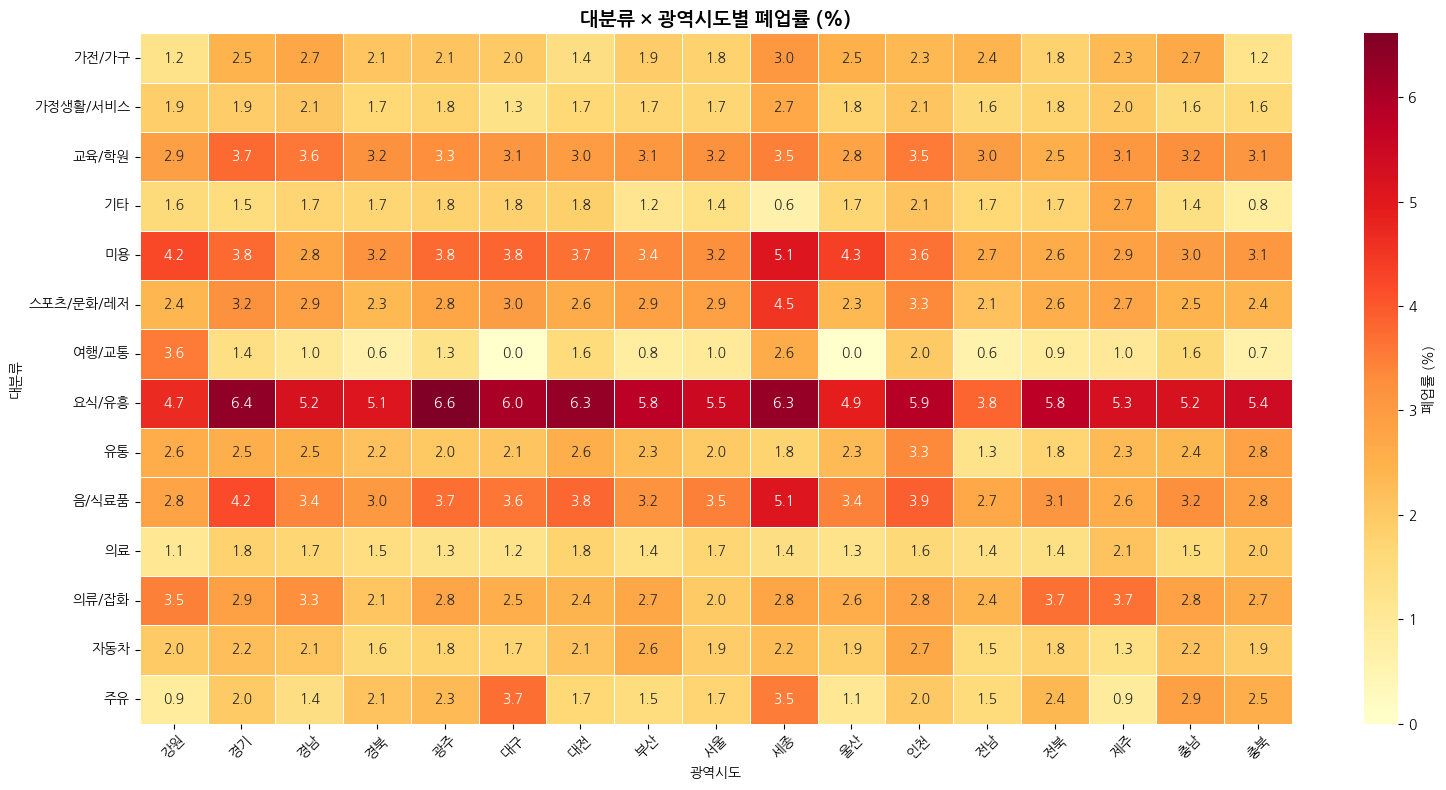

In [ ]:
# 대분류 x 광역시도 폐업률 피벗테이블
pivot = df.groupby(["대분류", "광역시도"])["폐업여부"].mean().unstack() * 100

# 그래프
fig, ax = plt.subplots(figsize=(16, 8))

sns.heatmap(
    pivot,
    ax=ax,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",      # 높을수록 진한 빨강
    linewidths=0.5,
    cbar_kws={"label": "폐업률 (%)"}
)

ax.set_title("대분류 × 광역시도별 폐업률 (%)", fontsize=14, fontweight="bold")
ax.set_xlabel("광역시도")
ax.set_ylabel("대분류")
ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()


지금까지 유의미한 변수 정리
* 대분류 → 폐업률 차이가 가장 크게 나타남
* 광역시도 → 단독보단 업종과 결합 시 유의미
* 개업연도 → 최근일수록 폐업률 높음

지도 시각화
* 목표 : 폐업률을 지도에 표현하여 한눈에 지역별로 볼수있게 만듦
* ["가맹점명", "X좌표", "Y좌표", "대분류", ] -> 주요 정보
* ["중분류", "광역시도", "폐업여부", "개업연도", "영업기간_년"] -> 부속정보


In [ ]:
map_cols = ["가맹점명", "X좌표", "Y좌표", "대분류", "중분류", "광역시도", "폐업여부", "개업연도", "영업기간_년"]
df_map = df[df["X좌표"].notna()][map_cols].copy()


df_map.dtypes

df_map.head(3)

,가맹점명,X좌표,Y좌표,대분류,중분류,광역시도,폐업여부,개업연도,영업기간_년
0,섬꽃농원,125.934316,34.700156,스포츠/문화/레저,스포츠/문화/레저용품,전남,0,2023,2.893151
1,대성마트,126.261589,33.415734,유통,할인점/슈퍼마켓,제주,0,2020,5.857534
2,속편한드림 내과의원,126.477798,33.484445,의료,병원,제주,0,2022,3.632877


In [ ]:
import requests
import json

# download_url 확인
api_url = "https://api.github.com/repos/southkorea/southkorea-maps/contents/kostat/2018/json/skorea-municipalities-2018-geo.json"
response = requests.get(api_url)
content = response.json()

# download_url로 직접 파일 받기
download_url = content['download_url']
print(f"download_url: {download_url}")

geo_response = requests.get(download_url)
geo_data = geo_response.json()

print(f"✅ 로드 성공: {len(geo_data['features'])}개")
print(geo_data['features'][0]['properties'])

download_url: https://raw.githubusercontent.com/southkorea/southkorea-maps/master/kostat/2018/json/skorea-municipalities-2018-geo.json
✅ 로드 성공: 250개
{'name': '종로구', 'base_year': '2018', 'name_eng': 'Jongno-gu', 'code': '11010'}


In [ ]:
import folium
from folium.plugins import MarkerCluster


In [ ]:

# ────────────────────────────────────────────
# 1. 시군구별 폐업률 계산
# ────────────────────────────────────────────
sigungu_stats = (
    df.groupby("시군구")
    .agg(
        폐업률=("폐업여부", "mean"),
        총가맹점=("가맹점명", "count"),
    )
    .reset_index()
)
sigungu_stats["폐업률"] = (sigungu_stats["폐업률"] * 100).round(2)

# ────────────────────────────────────────────
# 2. 시군구별 폐업률 낮은 업종 Top3
# ────────────────────────────────────────────
top3 = (
    df.groupby(["시군구", "대분류", "중분류"])["폐업여부"]
    .mean()
    .reset_index()
    .rename(columns={"폐업여부": "업종폐업률"})
    .sort_values(["시군구", "업종폐업률"])
    .groupby("시군구")
    .head(3)
    .groupby("시군구")
    .apply(lambda x: "<br>".join(
        [f"{r['대분류']} > {r['중분류']}: {r['업종폐업률']*100:.1f}%"
         for _, r in x.iterrows()]
    ))
    .reset_index()
    .rename(columns={0: "top3_text"})
)
sigungu_stats = sigungu_stats.merge(top3, on="시군구", how="left")

# ────────────────────────────────────────────
# 3. 지도 생성
# ────────────────────────────────────────────
m = folium.Map(location=[36.5, 127.5], zoom_start=7, tiles="CartoDB positron")

# Choropleth
folium.Choropleth(
    geo_data=geo_data,
    data=sigungu_stats,
    columns=["시군구", "폐업률"],
    key_on="feature.properties.name",
    fill_color="YlOrRd",
    fill_opacity=0.7,
    line_opacity=0.3,
    legend_name="폐업률 (%)",
    nan_fill_color="lightgrey",
).add_to(m)

# 팝업 마커
for _, row in sigungu_stats.iterrows():
    for feature in geo_data["features"]:
        if feature["properties"]["name"] == row["시군구"]:
            coords = feature["geometry"]["coordinates"]
            geo_type = feature["geometry"]["type"]
            if geo_type == "Polygon":
                lngs = [c[0] for c in coords[0]]
                lats = [c[1] for c in coords[0]]
            else:
                lngs = [c[0] for poly in coords for c in poly[0]]
                lats = [c[1] for poly in coords for c in poly[0]]
            center = [sum(lats)/len(lats), sum(lngs)/len(lngs)]

            folium.Marker(
                location=center,
                icon=folium.DivIcon(html=""),
                popup=folium.Popup(
                    f"""
                    <b>{row['시군구']}</b><br>
                    전체 폐업률: <b>{row['폐업률']}%</b><br>
                    총 가맹점 수: {row['총가맹점']:,}개<br><br>
                    <b>📌 폐업률 낮은 업종 Top3</b><br>
                    {row['top3_text']}
                    """,
                    max_width=250
                )
            ).add_to(m)
            break

m.save("map_choropleth.html")
print("✅ 저장 완료 → map_choropleth.html")
m

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
import folium
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# ────────────────────────────────────────────
# 1. 시군구별 위험 점수 산출
# ────────────────────────────────────────────
sigungu_stats = (
    df.groupby("시군구")
    .agg(
        폐업률        = ("폐업여부", "mean"),
        경쟁밀도      = ("상권_소분류_밀도", "mean"),
        다양성        = ("상권_대분류_다양성", "mean"),
        가맹점수      = ("가맹점명", "count"),
    )
    .query("가맹점수 >= 50")
    .reset_index()
)

# 0~1 정규화
scaler = MinMaxScaler()
sigungu_stats[["폐업률_n", "경쟁밀도_n", "다양성_n"]] = scaler.fit_transform(
    sigungu_stats[["폐업률", "경쟁밀도", "다양성"]]
)

# 위험 점수: 폐업률 50% + 경쟁밀도 30% + 다양성 부족 20%
sigungu_stats["위험점수"] = (
    sigungu_stats["폐업률_n"]       * 0.5 +
    sigungu_stats["경쟁밀도_n"]     * 0.3 +
    (1 - sigungu_stats["다양성_n"]) * 0.2
)

sigungu_stats["위험등급"] = pd.cut(
    sigungu_stats["위험점수"],
    bins=[0, 0.33, 0.66, 1.01],
    labels=["안전권", "보통권", "위험권"]
).astype(str)

sigungu_stats["폐업률_pct"] = (sigungu_stats["폐업률"] * 100).round(2)
sigungu_stats["경쟁밀도_r"] = sigungu_stats["경쟁밀도"].round(1)
sigungu_stats["다양성_r"]   = sigungu_stats["다양성"].round(1)

# ────────────────────────────────────────────
# 2. 등급별 컬러 매핑 (Choropleth 대신 GeoJson 직접 사용)
# ────────────────────────────────────────────
grade_color = {
    "안전권": "#2196F3",
    "보통권": "#FFC107",
    "위험권": "#F44336",
    "nan"  : "#BDBDBD",
}

stats_dict = sigungu_stats.set_index("시군구").to_dict(orient="index")

def style_fn(feature):
    name  = feature["properties"]["name"]
    row   = stats_dict.get(name, {})
    grade = row.get("위험등급", "nan")
    return {
        "fillColor"   : grade_color.get(grade, "#BDBDBD"),
        "color"       : "white",
        "weight"      : 0.5,
        "fillOpacity" : 0.75,
    }

def highlight_fn(feature):
    return {
        "fillColor"  : "#FFD700",
        "color"      : "#FF6F00",
        "weight"     : 2.5,
        "fillOpacity": 0.9,
    }

# ────────────────────────────────────────────
# 3. 지도 생성
# ────────────────────────────────────────────
m1 = folium.Map(location=[36.5, 127.5], zoom_start=7, tiles="CartoDB positron")

folium.GeoJson(
    geo_data,
    style_function    =style_fn,
    highlight_function=highlight_fn,
    tooltip=folium.GeoJsonTooltip(
        fields  =["name"],
        aliases =["시군구"],
        sticky  =True,
    )
).add_to(m1)

# ── 팝업 마커 (기존 코드와 동일한 방식) ──
for _, row in sigungu_stats.iterrows():
    for feature in geo_data["features"]:
        if feature["properties"]["name"] == row["시군구"]:
            coords   = feature["geometry"]["coordinates"]
            geo_type = feature["geometry"]["type"]
            if geo_type == "Polygon":
                lngs = [c[0] for c in coords[0]]
                lats = [c[1] for c in coords[0]]
            else:
                lngs = [c[0] for poly in coords for c in poly[0]]
                lats = [c[1] for poly in coords for c in poly[0]]
            center = [sum(lats)/len(lats), sum(lngs)/len(lngs)]

            grade = row["위험등급"]
            emoji = {"안전권": "🟢", "보통권": "🟡", "위험권": "🔴"}.get(grade, "⚪")

            folium.Marker(
                location=center,
                icon=folium.DivIcon(html=""),
                popup=folium.Popup(
                    f"""
                    <div style="font-family:'Malgun Gothic',sans-serif; font-size:13px;">
                        <b>{row['시군구']}</b><br>
                        {emoji} 위험 등급 : <b>{grade}</b><br>
                        <hr style="margin:4px 0;">
                        📉 폐업률 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;: <b>{row['폐업률_pct']}%</b><br>
                        ⚔️ 경쟁 밀도 : <b>{row['경쟁밀도_r']}</b><br>
                        🏪 업종 다양성 : <b>{row['다양성_r']}</b><br>
                        📊 가맹점 수 : <b>{int(row['가맹점수']):,}개</b><br>
                        <hr style="margin:4px 0;">
                        <span style="font-size:11px;color:#888;">
                        위험점수 = 폐업률(50%) + 경쟁밀도(30%) + 다양성부족(20%)
                        </span>
                    </div>
                    """,
                    max_width=260
                )
            ).add_to(m1)
            break

# ── 범례 ──
legend1_html = """
<div style="
    position:fixed; bottom:40px; left:40px; z-index:1000;
    background:white; padding:16px 20px; border-radius:10px;
    border:1px solid #ccc; font-family:'Malgun Gothic',sans-serif;
    box-shadow:2px 2px 8px rgba(0,0,0,0.15);
">
    <p style="font-size:15px;font-weight:bold;margin:0 0 10px 0;">🏪 창업 위험 등급</p>
    <p style="margin:5px 0;">
        <span style="background:#F44336;padding:3px 14px;border-radius:3px;"></span>
        &nbsp;<b>위험권</b> — 폐업률 높음 · 경쟁 과밀
    </p>
    <p style="margin:5px 0;">
        <span style="background:#FFC107;padding:3px 14px;border-radius:3px;"></span>
        &nbsp;<b>보통권</b> — 전국 평균 수준
    </p>
    <p style="margin:5px 0;">
        <span style="background:#2196F3;padding:3px 14px;border-radius:3px;"></span>
        &nbsp;<b>안전권</b> — 폐업률 낮음 · 경쟁 여유
    </p>
    <p style="margin:5px 0;">
        <span style="background:#BDBDBD;padding:3px 14px;border-radius:3px;"></span>
        &nbsp;<b>데이터 없음</b>
    </p>
    <hr style="margin:10px 0;">
    <p style="font-size:11px;color:#666;margin:0;">
        위험점수 = 폐업률(50%) + 경쟁밀도(30%) + 다양성부족(20%)
    </p>
</div>
"""
m1.get_root().html.add_child(folium.Element(legend1_html))

# ── 제목 ──
title1_html = """
<div style="
    position:fixed; top:16px; left:50%; transform:translateX(-50%);
    z-index:1000; background:white; padding:10px 24px;
    border-radius:8px; border:1px solid #ccc;
    font-family:'Malgun Gothic',sans-serif;
    font-size:17px; font-weight:bold;
    box-shadow:2px 2px 8px rgba(0,0,0,0.12);
">
    📍 시군구별 창업 위험 등급 지도
</div>
"""
m1.get_root().html.add_child(folium.Element(title1_html))

m1.save("map_risk_grade.html")
print("✅ 저장 완료 → map_risk_grade.html")
m1

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
import folium
import pandas as pd
import numpy as np

# ────────────────────────────────────────────
# 1. 시군구별 통계 집계
# ────────────────────────────────────────────
recent = df[df["개업연도"] >= df["개업연도"].max() - 2]  # 최근 3년

sigungu_density = (
    df.groupby("시군구")["상권_소분류_밀도"]
    .mean()
    .reset_index(name="평균경쟁밀도")
)

sigungu_recent = (
    recent.groupby("시군구")
    .size()
    .reset_index(name="최근개업수")
)

sigungu_closure = (
    df.groupby("시군구")["폐업여부"]
    .mean()
    .mul(100).round(2)
    .reset_index(name="폐업률")
)

sigungu_region = (
    df[["시군구", "광역시도"]]
    .drop_duplicates("시군구")
)

bubble_df = (
    sigungu_density
    .merge(sigungu_recent,  on="시군구", how="inner")
    .merge(sigungu_closure, on="시군구", how="inner")
    .merge(sigungu_region,  on="시군구", how="left")
    .query("최근개업수 >= 30")
)

# 버블 크기 정규화 (6 ~ 38 픽셀)
mn, mx = bubble_df["최근개업수"].min(), bubble_df["최근개업수"].max()
bubble_df["버블크기"] = ((bubble_df["최근개업수"] - mn) / (mx - mn) * 32 + 6).round(1)

# 경쟁밀도 4분위 등급
bubble_df["밀도등급"] = pd.qcut(
    bubble_df["평균경쟁밀도"], q=4,
    labels=["낮음", "보통", "높음", "매우높음"]
).astype(str)

density_color = {
    "낮음"   : "#2196F3",
    "보통"   : "#4CAF50",
    "높음"   : "#FF9800",
    "매우높음": "#F44336",
}

# ────────────────────────────────────────────
# 2. 기존 코드와 동일하게 GeoJSON에서 중심 좌표 추출
# ────────────────────────────────────────────
center_coords = {}
for feature in geo_data["features"]:
    name     = feature["properties"]["name"]
    coords   = feature["geometry"]["coordinates"]
    geo_type = feature["geometry"]["type"]
    if geo_type == "Polygon":
        lngs = [c[0] for c in coords[0]]
        lats = [c[1] for c in coords[0]]
    else:
        lngs = [c[0] for poly in coords for c in poly[0]]
        lats = [c[1] for poly in coords for c in poly[0]]
    center_coords[name] = [sum(lats)/len(lats), sum(lngs)/len(lngs)]

# ────────────────────────────────────────────
# 3. 지도 생성
# ────────────────────────────────────────────
m4 = folium.Map(location=[36.5, 127.5], zoom_start=7, tiles="CartoDB positron")

# 배경 시군구 경계선만 얇게 표시
folium.GeoJson(
    geo_data,
    style_function=lambda x: {
        "fillColor"  : "#f5f5f5",
        "color"      : "#aaaaaa",
        "weight"     : 0.5,
        "fillOpacity": 0.3,
    }
).add_to(m4)

# 버블 마커
for _, row in bubble_df.iterrows():
    center = center_coords.get(row["시군구"])
    if center is None:
        continue

    color = density_color.get(row["밀도등급"], "#9E9E9E")

    # 상권 상태 진단
    high_density = row["밀도등급"] == "매우높음"
    high_open    = row["최근개업수"] >= bubble_df["최근개업수"].quantile(0.75)
    low_density  = row["밀도등급"] == "낮음"
    mid_open     = row["최근개업수"] >= bubble_df["최근개업수"].quantile(0.5)

    if high_density and high_open:
        status = "🔴 과열 상권 — 신규 진입 주의"
    elif low_density and mid_open:
        status = "🟢 블루오션 — 성장 가능성"
    elif low_density:
        status = "🔵 저경쟁 상권"
    elif high_density:
        status = "🟠 고경쟁 상권"
    else:
        status = "🟡 일반 상권"

    folium.CircleMarker(
        location    =center,
        radius      =row["버블크기"],
        color       =color,
        fill        =True,
        fill_color  =color,
        fill_opacity=0.65,
        weight      =1.5,
        popup=folium.Popup(
            f"""
            <div style="font-family:'Malgun Gothic',sans-serif; font-size:13px;">
                <b>{row['시군구']}</b>
                <span style="color:#888;font-size:11px;"> ({row.get('광역시도','')})</span><br>
                {status}<br>
                <hr style="margin:4px 0;">
                📈 최근 3년 개업 수 : <b>{int(row['최근개업수']):,}개</b><br>
                ⚔️ 평균 경쟁 밀도 &nbsp;: <b>{row['평균경쟁밀도']:.1f}</b>
                <span style="color:#888;">({row['밀도등급']})</span><br>
                📉 전체 폐업률 &nbsp;&nbsp;&nbsp;: <b>{row['폐업률']}%</b>
            </div>
            """,
            max_width=260
        )
    ).add_to(m4)

# ── 범례 ──
legend4_html = """
<div style="
    position:fixed; bottom:40px; left:40px; z-index:1000;
    background:white; padding:16px 20px; border-radius:10px;
    border:1px solid #ccc; font-family:'Malgun Gothic',sans-serif;
    box-shadow:2px 2px 8px rgba(0,0,0,0.15);
">
    <p style="font-size:15px;font-weight:bold;margin:0 0 10px 0;">🫧 버블 범례</p>
    <p style="font-size:12px;margin:0 0 6px 0;">
        🔵 <b>버블 크기</b> = 최근 3년 신규 개업 수<br>
        🎨 <b>버블 색상</b> = 평균 경쟁 밀도 분위
    </p>
    <hr style="margin:8px 0;">
    <p style="margin:5px 0;">
        <span style="background:#F44336;padding:3px 13px;border-radius:50%;"></span>
        &nbsp;<b>매우높음</b> — 4분위 (과열 주의)
    </p>
    <p style="margin:5px 0;">
        <span style="background:#FF9800;padding:3px 13px;border-radius:50%;"></span>
        &nbsp;<b>높음</b> — 3분위
    </p>
    <p style="margin:5px 0;">
        <span style="background:#4CAF50;padding:3px 13px;border-radius:50%;"></span>
        &nbsp;<b>보통</b> — 2분위
    </p>
    <p style="margin:5px 0;">
        <span style="background:#2196F3;padding:3px 13px;border-radius:50%;"></span>
        &nbsp;<b>낮음</b> — 1분위 (블루오션)
    </p>
    <hr style="margin:8px 0;">
    <p style="font-size:11px;color:#666;margin:0;">
        🔴 빨간 큰 버블 = 과열 상권<br>
        🔵 파란 큰 버블 = 블루오션
    </p>
</div>
"""
m4.get_root().html.add_child(folium.Element(legend4_html))

# ── 제목 ──
title4_html = """
<div style="
    position:fixed; top:16px; left:50%; transform:translateX(-50%);
    z-index:1000; background:white; padding:10px 24px;
    border-radius:8px; border:1px solid #ccc;
    font-family:'Malgun Gothic',sans-serif;
    font-size:17px; font-weight:bold;
    box-shadow:2px 2px 8px rgba(0,0,0,0.12);
">
    📍 시군구별 경쟁 밀도 × 신규 개업 수 버블 지도
</div>
"""
m4.get_root().html.add_child(folium.Element(title4_html))

m4.save("map_bubble.html")
print("✅ 저장 완료 → map_bubble.html")
m4

Output hidden; open in https://colab.research.google.com to view.

In [ ]:

# ═══════════════════════════════════════════
# 1. 생존 5년에 따라 정의
# 핵심 원칙: 개업 후 5년이 실제로 경과한 가맹점만 분석 대상
# ═══════════════════════════════════════════
기준일 = pd.Timestamp('today')
기준일_5년전 = 기준일 - pd.DateOffset(years=5)

print(f"분석 기준일: {기준일.date()}")
print(f"5년 전 기준: {기준일_5년전.date()}")
print(f"  → 이 날짜 이전 개업한 가맹점만 분석 대상")

# 개업일자로부터 5년이 경과한 가맹점만 필터
df_valid = df[df['개업일자'] <= 기준일_5년전].copy()

print(f"\n전체 데이터: {len(df):,}개")
print(f"5년 경과 가맹점: {len(df_valid):,}개")
print(f"제외된 가맹점 (5년 미경과): {len(df)-len(df_valid):,}개")

# 생존5년 재정의
# 1 = 5년 이상 영업 (폐업 안 했거나, 폐업했어도 1825일 이상 영업)
# 0 = 5년 내 폐업
df_valid['생존5년'] = (df_valid['영업기간_일'] >= 1825).astype(int)

print(f"\n=== 재정의 후 클래스 분포 ===")
print(df_valid['생존5년'].value_counts())
print(f"생존 비율: {df_valid['생존5년'].mean():.1%}")
print(f"폐업 비율: {1 - df_valid['생존5년'].mean():.1%}")

# 교차 검증
print(f"\n=== 교차 확인 ===")
print(df_valid.groupby(['생존5년', '폐업여부']).size())

분석 기준일: 2026-05-03
5년 전 기준: 2021-05-03
  → 이 날짜 이전 개업한 가맹점만 분석 대상

전체 데이터: 1,048,573개
5년 경과 가맹점: 708,156개
제외된 가맹점 (5년 미경과): 340,417개

=== 재정의 후 클래스 분포 ===
생존5년
1    702697
0      5459
Name: count, dtype: int64
생존 비율: 99.2%
폐업 비율: 0.8%

=== 교차 확인 ===
생존5년  폐업여부
0     1         5459
1     0       691950
      1        10747
dtype: int64


In [ ]:
# ═══════════════════════════════════════════
#  2. 파생변수 재계산 (df_valid 기준)
# ═══════════════════════════════════════════

# 경쟁밀도, 다양성 재계산
df_valid['상권_소분류_밀도'] = (
    df_valid.groupby(['읍면동', '소분류'])['가맹점명']
    .transform('count')
)
df_valid['상권_대분류_다양성'] = (
    df_valid.groupby('읍면동')['대분류']
    .transform('nunique')
)

# ═══════════════════════════════════════════
# 3. 모델 데이터셋 구성
# ═══════════════════════════════════════════
features = ['대분류', '광역시도', '개업연도', '개업월',
            '상권_소분류_밀도', '상권_대분류_다양성']
target   = '생존5년'

df_m = df_valid[features + [target]].dropna().copy()

# 샘플링 (불균형 비율 확인 후 결정)
생존비율 = df_m[target].mean()
print(f"최종 생존 비율: {생존비율:.1%}")

# 50만 초과 시 샘플링
if len(df_m) > 500_000:
    df_m = df_m.sample(n=500_000, random_state=42)
    print(f"샘플링 적용: 500,000개")

# ═══════════════════════════════════════════
#  4. Target Encoding (누수 방지 — train 기준)
# ═══════════════════════════════════════════
from sklearn.model_selection import train_test_split

# 먼저 분리
X_raw = df_m[features]
y     = df_m[target]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# train 기준으로만 인코딩 맵 계산
X_train = X_train_raw.copy()
X_test  = X_test_raw.copy()

for col in ['대분류', '광역시도']:
    train_df_tmp = pd.concat([X_train[[col]], y_train], axis=1)
    enc_map = train_df_tmp.groupby(col)[target].mean()

    X_train[f'{col}_enc'] = X_train[col].map(enc_map)
    X_test[f'{col}_enc']  = X_test[col].map(enc_map)

    # test에 없는 카테고리는 전체 평균으로 대체
    global_mean = y_train.mean()
    X_test[f'{col}_enc'] = X_test[f'{col}_enc'].fillna(global_mean)

feature_cols = ['대분류_enc', '광역시도_enc', '개업연도',
                '개업월', '상권_소분류_밀도', '상권_대분류_다양성']

X_train = X_train[feature_cols]
X_test  = X_test[feature_cols]

print(f"\nTrain: {len(X_train):,} | Test: {len(X_test):,}")
print(f"Train 클래스 분포:\n{y_train.value_counts()}")

최종 생존 비율: 99.2%
샘플링 적용: 500,000개

Train: 400,000 | Test: 100,000
Train 클래스 분포:
생존5년
1    396895
0      3105
Name: count, dtype: int64


In [ ]:
# ═══════════════════════════════════════════
# 5. 모델 학습 (동일)
# ═══════════════════════════════════════════
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
matplotlib.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

pos  = (y_train == 1).sum()
neg  = (y_train == 0).sum()
ratio = neg / pos  # XGBoost scale_pos_weight용

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=300, random_state=42, class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, max_depth=8,
        min_samples_leaf=50, class_weight='balanced',
        random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100, max_depth=5, learning_rate=0.1,
        subsample=0.8, scale_pos_weight=ratio,
        eval_metric='logloss', random_state=42, n_jobs=-1
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=100, max_depth=5, learning_rate=0.1,
        subsample=0.8, class_weight='balanced',
        random_state=42, n_jobs=-1, verbose=-1
    ),
}

results = {}
for name, m in models.items():
    print(f"⏳ {name} 학습 중...")
    m.fit(X_train, y_train)
    y_prob   = m.predict_proba(X_test)[:, 1]
    y_pred   = (y_prob >= 0.5).astype(int)
    test_auc = roc_auc_score(y_test, y_prob)
    results[name] = {
        'model': m, 'y_prob': y_prob,
        'y_pred': y_pred, 'test_auc': test_auc
    }
    print(f"  ✅ {name} | AUC: {test_auc:.4f}")

best_name  = max(results, key=lambda k: results[k]['test_auc'])
best_model = results[best_name]['model']
print(f"\n🏆 최고 성능 모델: {best_name} ({results[best_name]['test_auc']:.4f})")

⏳ Logistic Regression 학습 중...
  ✅ Logistic Regression | AUC: 0.8927
⏳ Random Forest 학습 중...
  ✅ Random Forest | AUC: 0.8990
⏳ XGBoost 학습 중...
  ✅ XGBoost | AUC: 0.9009
⏳ LightGBM 학습 중...
  ✅ LightGBM | AUC: 0.8999

🏆 최고 성능 모델: XGBoost (0.9009)


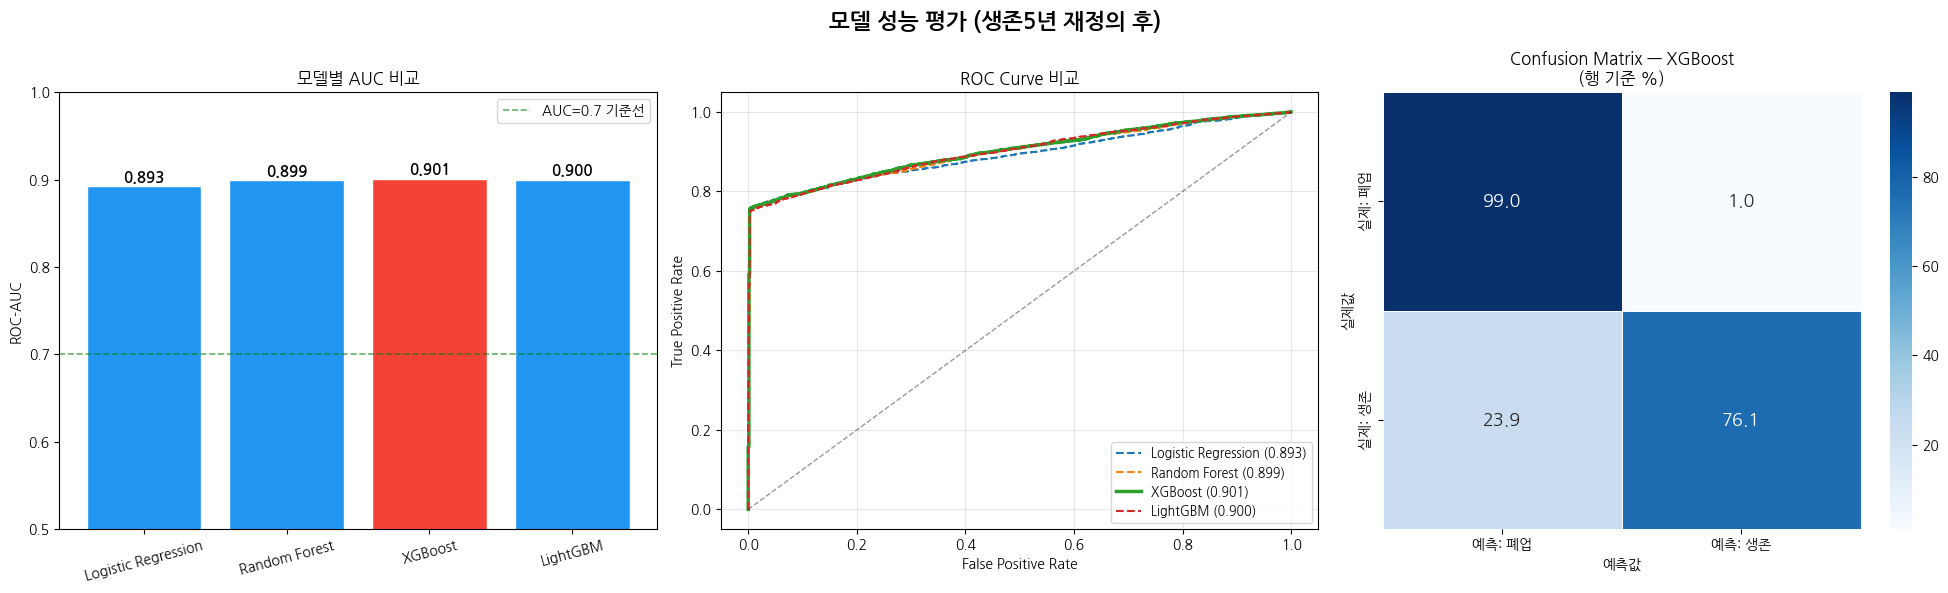


📊 XGBoost 상세 리포트
              precision    recall  f1-score   support

     5년 내 폐업       0.03      0.99      0.06       776
       5년 생존       1.00      0.76      0.86     99224

    accuracy                           0.76    100000
   macro avg       0.52      0.88      0.46    100000
weighted avg       0.99      0.76      0.86    100000



In [ ]:
# ═══════════════════════════════════════════
#  6. 시각화 (동일)
# ═══════════════════════════════════════════
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('모델 성능 평가 (생존5년 재정의 후)', fontsize=16, fontweight='bold')

names     = list(results.keys())
test_aucs = [results[n]['test_auc'] for n in names]
colors_bar = ['#F44336' if n == best_name else '#2196F3' for n in names]

bars = axes[0].bar(names, test_aucs, color=colors_bar, edgecolor='white')
axes[0].axhline(0.7, color='green', linestyle='--', linewidth=1.2,
                alpha=0.6, label='AUC=0.7 기준선')
axes[0].set_ylim(0.5, 1.0)
axes[0].set_ylabel('ROC-AUC')
axes[0].set_title('모델별 AUC 비교')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, test_aucs):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    lw = 2.5 if name == best_name else 1.5
    ls = '-'  if name == best_name else '--'
    axes[1].plot(fpr, tpr, linewidth=lw, linestyle=ls,
                 label=f"{name} ({res['test_auc']:.3f})")
axes[1].plot([0,1],[0,1],'k--', linewidth=1, alpha=0.4)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve 비교')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

cm     = confusion_matrix(y_test, results[best_name]['y_pred'])
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            ax=axes[2], linewidths=0.5,
            xticklabels=['예측: 폐업', '예측: 생존'],
            yticklabels=['실제: 폐업', '실제: 생존'],
            annot_kws={'size': 13})
axes[2].set_title(f'Confusion Matrix — {best_name}\n(행 기준 %)')
axes[2].set_ylabel('실제값')
axes[2].set_xlabel('예측값')
plt.tight_layout()
plt.show()

print(f"\n{'='*50}")
print(f"📊 {best_name} 상세 리포트")
print(f"{'='*50}")
print(classification_report(
    y_test, results[best_name]['y_pred'],
    target_names=['5년 내 폐업', '5년 생존']
))

In [ ]:
import folium
import pandas as pd

# ═══════════════════════════════════════════
# 0. df_pred 생성
# ═══════════════════════════════════════════
# best_model은 이전에 학습된 XGBoost 모델
y_prob_best = best_model.predict_proba(X_test)[:, 1]

df_pred = X_test_raw.copy()
df_pred['생존확률'] = (y_prob_best * 100).round(1)
df_pred['생존5년'] = y_test.values

# '시군구' 컬럼을 df_pred에 추가 (df_valid에서 병합)
df_pred = df_pred.merge(df_valid[['시군구']], left_index=True, right_index=True, how='left')

# ── 1. 업종 선택 ──
TARGET_INDUSTRY = '요식/유흥'  # 바꾸면 다른 업종 지도 출력

industry_map = (
    df_pred[df_pred['대분류'] == TARGET_INDUSTRY]
    .groupby('시군구')['생존확률']
    .mean()
    .round(1)
    .reset_index()
    .rename(columns={'생존확률': '생존확률_pct'})
)

print(f"시군구 수: {len(industry_map)}")
print(industry_map.sort_values('생존확률_pct', ascending=False).head(5))
print(industry_map.sort_values('생존확률_pct', ascending=True).head(5))

시군구 수: 213
     시군구   생존확률_pct
42   김제시  99.800003
161  장흥군  99.800003
138  예천군  99.800003
30   괴산군  99.699997
131  영동군  99.699997
     시군구  생존확률_pct
133  영암군       9.6
36   군위군      10.0
134  영월군      10.3
31   구례군      10.7
21   곡성군      10.7


In [ ]:
# ── 2. 지도 생성 ──
m = folium.Map(location=[36.5, 127.5], zoom_start=7, tiles='CartoDB positron')

folium.Choropleth(
    geo_data       = geo_data,
    data           = industry_map,
    columns        = ['시군구', '생존확률_pct'],
    key_on         = 'feature.properties.name',
    fill_color     = 'RdYlGn',
    fill_opacity   = 0.7,
    line_opacity   = 0.3,
    legend_name    = f'{TARGET_INDUSTRY} 5년 생존 확률 (%)',
    nan_fill_color = 'lightgrey',
).add_to(m)

# ── 3. 팝업 ──
for _, row in industry_map.iterrows():
    for feature in geo_data['features']:
        if feature['properties']['name'] == row['시군구']:
            coords   = feature['geometry']['coordinates']
            geo_type = feature['geometry']['type']
            if geo_type == 'Polygon':
                lngs = [c[0] for c in coords[0]]
                lats = [c[1] for c in coords[0]]
            else:
                lngs = [c[0] for poly in coords for c in poly[0]]
                lats = [c[1] for poly in coords for c in poly[0]]
            center = [sum(lats)/len(lats), sum(lngs)/len(lngs)]

            pct = row['생존확률_pct']
            grade = '🟢 유망' if pct >= 60 else ('🟡 보통' if pct >= 40 else '🔴 위험')

            folium.Marker(
                location = center,
                icon     = folium.DivIcon(html=''),
                popup    = folium.Popup(
                    f"<b>{row['시군구']}</b><br>"
                    f"업종: {TARGET_INDUSTRY}<br>"
                    f"5년 생존 확률: <b>{pct}%</b><br>"
                    f"등급: {grade}",
                    max_width=200
                )
            ).add_to(m)
            break

# ── 4. 제목 ──
m.get_root().html.add_child(folium.Element(f"""
<div style="
    position:fixed; top:16px; left:50%; transform:translateX(-50%);
    z-index:1000; background:white; padding:10px 20px;
    border-radius:8px; border:1px solid #ccc;
    font-size:15px; font-weight:bold;
">
    📍 {TARGET_INDUSTRY} — 시군구별 5년 생존 확률 예측 지도
</div>
"""))

# 파일명에 부적절한 문자 대체
sanitized_industry_name = TARGET_INDUSTRY.replace('/', '_')
m.save(f'map_survival_{sanitized_industry_name}.html')
print(f'✅ 저장 완료')
m

Output hidden; open in https://colab.research.google.com to view.